# Revision Package Analysis

Reads the artifacts in `revision/` and establishes what each one shows,
what is missing, and which task-tracker items the evidence closes.

This notebook is **read-only**. It performs no training, no attack runs,
and writes nothing outside itself.

In [38]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# notebooks/ sits one level under the repo root
REPO     = Path.cwd().parent
REVISION = REPO / "revision"
TABLES   = REVISION / "tables" / "csv"
FIGPNG   = REVISION / "figures" / "png"
LOGS     = REVISION / "logs"

assert REVISION.is_dir(), f"revision/ not found from {Path.cwd()}"

# Load every table by stem; keys match the filenames in MANIFEST.csv
T = {p.stem: pd.read_csv(p) for p in sorted(TABLES.glob("*.csv"))}

manifest = pd.read_csv(REVISION / "MANIFEST.csv")

print(f"repo root : {REPO}")
print(f"tables    : {len(T)}")
print(f"manifest  : {len(manifest)} rows\n")

for name, df in T.items():
    print(f"  {name:<32} {df.shape[0]:>3} rows x {df.shape[1]:>2} cols")

repo root : /Users/amar/Desktop/Architecture Resilience
tables    : 9
manifest  : 51 rows

  baseline_accuracy_matrix          30 rows x  9 cols
  baseline_leakage_all_pairs        30 rows x 10 cols
  bound_violations                  41 rows x 12 cols
  config_inventory                  30 rows x 22 cols
  dataset_characteristics            6 rows x 12 cols
  evaluation_set_sizes               6 rows x  9 cols
  residual_leakage_eps1             30 rows x 19 cols
  rho_by_epsilon                    12 rows x 22 cols
  within_pair_correlations           4 rows x 13 cols


## Tier 0 — Known gaps

Read this before any table. Two of the nine tables carry `[MISSING: …]`
placeholders; the other seven are complete. Separately, 36 DP-DNN rows are
absent from the upstream utility data, which thins one figure to n=26.

Nothing here was estimated or filled in. A missing cell is a missing cell.

In [39]:
# ---- 1. MISSING placeholders, per table and column ----------------------
rows = []
for name, df in T.items():
    s = df.astype(str)
    for col in s.columns:
        n = s[col].str.startswith("[MISSING", na=False).sum()
        if n:
            rows.append({"table": name, "column": col,
                         "n_missing": int(n), "n_rows": len(df)})

missing = pd.DataFrame(rows)

if missing.empty:
    print("No [MISSING] placeholders found.")
else:
    display(Markdown("**Cells explicitly marked missing**"))
    display(missing.sort_values(["table", "n_missing"], ascending=[True, False])
                   .reset_index(drop=True))


No [MISSING] placeholders found.


In [40]:
db_char = pd.read_csv(TABLES / "dataset_characteristics.csv")

db_char.head()

,dataset,dataset_dir,n_samples,n_features,task,n_classes,class_balance,n_train,n_test,source_url,real_or_synthetic,provenance
0,Gallstone Status,GALLSTONE,319,38,Binary classification,2,0: 161 (50.5%); 1: 158 (49.5%),255,64,https://archive.ics.uci.edu/dataset/1150/galls...,No,Ankara VM Medical Park Hospital (Clinical Data)
1,Breast Cancer Wisconsin (Diagnostic),BCP,569,30,Binary classification,2,0: 357 (62.7%); 1: 212 (37.3%),455,114,https://archive.ics.uci.edu/dataset/17/breast+...,No,University of Wisconsin (FNA Images)
2,Cancer Risk Prediction,CANCER_RISK,1500,8,Binary classification,2,0: 943 (62.9%); 1: 557 (37.1%),1200,300,https://www.kaggle.com/datasets/rabieelkharoua...,Yes,Synthetically generated by author
3,Kidney Stone Risk,KIDNEY_STONE,4000,23,Binary classification,2,0: 2433 (60.8%); 1: 1567 (39.2%),3200,800,https://www.kaggle.com/datasets/omarayman15/ki...,Unknown,Unknown
4,Lung Cancer Risk Level,LUNG_CANCER,50000,23,3-class classification,3,0: 15114 (30.2%); 1: 16454 (32.9%); 2: 18432 (...,40000,10000,https://www.kaggle.com/datasets/himabindumarpi...,Yes,Unverified (widely considered synthetic)


In [41]:
# ---- 2. Upstream absence: 36 DP-DNN rows -------------------------------
util = pd.read_csv(REPO / "Results" / "dataset_results" / "consolidated_data.csv")

dp = util[util["variant"] == "dp"]
absent = dp[dp["exported_model_accuracy"].isna()]

print(f"DP rows total          : {len(dp)}")
print(f"Missing exported acc   : {len(absent)}")
print(f"Also missing n_runs    : {absent['n_runs'].isna().sum()}\n")

display(Markdown("**Which configurations are affected**"))
display(
    absent.groupby(["dataset", "model"])
          .agg(n_epsilons=("epsilon", "nunique"),
               eps_min=("epsilon", "min"),
               eps_max=("epsilon", "max"))
          .reset_index()
)

# Confirm the absence is confined to DP-DNN and not leaking elsewhere
other = absent[absent["model"] != "DP-DNN"]
assert other.empty, f"Unexpected: absence extends beyond DP-DNN\n{other}"
print("OK — absence is confined to DP-DNN.")

DP rows total          : 414
Missing exported acc   : 36
Also missing n_runs    : 36



**Which configurations are affected**

,dataset,model,n_epsilons,eps_min,eps_max
0,Breast Cancer,DP-DNN,9,0.1000,10.0000
1,Cancer Risk,DP-DNN,9,0.1000,10.0000
2,Diabetes,DP-DNN,9,0.1000,10.0000
3,Gallstone,DP-DNN,9,0.1000,10.0000


OK — absence is confined to DP-DNN.


In [42]:
# ---- Tier 1a: bound violations x evaluation resolution -----------------
bv   = T["bound_violations"].copy()
esz  = T["evaluation_set_sizes"][
           ["dataset", "min_resolvable_fpr", "min_resolvable_fpr_exceeds_1pct"]]

bv = bv.merge(esz, on="dataset", how="left", validate="many_to_one")

# Denominator: total DP LiRA configurations attacked
mia = pd.read_csv(REPO / "Results" / "attack_results" / "consolidated_mia_data.csv")
n_dp_lira = len(mia[(mia["attack"] == "lira") & (mia["variant"] == "dp")])

print(f"DP LiRA configurations : {n_dp_lira}")
print(f"Apparent violations    : {len(bv)}  ({len(bv)/n_dp_lira:.1%})")
print(f"Survive CI test        : {(bv['ci_low_exceeds_bound'] == 'yes').sum()}")
print(f"Overshoot ratio range  : {bv['ratio_tpr_over_bound'].min():.2f}x "
      f"– {bv['ratio_tpr_over_bound'].max():.2f}x")

DP LiRA configurations : 270
Apparent violations    : 41  (15.2%)
Survive CI test        : 3
Overshoot ratio range  : 1.01x – 1.91x


In [43]:
display(Markdown("**Distribution across the budget grid**"))
display(pd.crosstab(bv["epsilon"], bv["family"], margins=True, margins_name="total"))

assert (bv["epsilon"] < 1.0).all(), \
    f"Violation at eps >= 1.0:\n{bv[bv['epsilon'] >= 1.0]}"
print(f"OK — all violations at eps <= {bv['epsilon'].max()}; none at the "
      f"eps=1.0 operating point.")

**Distribution across the budget grid**

family,DNN,GNB,LR,RF,SVM,total
epsilon,,,,,,
0.1000,3,3,4,3,4,17
0.2000,3,4,4,2,3,16
0.4000,3,1,2,1,1,8
total,9,8,10,6,8,41


OK — all violations at eps <= 0.4; none at the eps=1.0 operating point.


In [44]:
display(Markdown("**Violations vs. evaluation-set size**"))
by_ds = (bv.groupby("dataset")
           .agg(n_violations=("epsilon", "size"),
                max_ratio=("ratio_tpr_over_bound", "max"),
                n_survive=("ci_low_exceeds_bound", lambda s: (s == "yes").sum()))
           .reset_index()
           .merge(T["evaluation_set_sizes"][["dataset", "n_nonmembers",
                                             "min_resolvable_fpr"]], on="dataset")
           .sort_values("n_nonmembers"))

# datasets with zero violations must be shown too, or the pattern is invisible
absent_ds = set(T["evaluation_set_sizes"]["dataset"]) - set(bv["dataset"])
print(f"Datasets with NO violations: {sorted(absent_ds)}")
display(by_ds)

**Violations vs. evaluation-set size**

Datasets with NO violations: ['Diabetes', 'Lung Cancer']


,dataset,n_violations,max_ratio,n_survive,n_nonmembers,min_resolvable_fpr
2,Gallstone,9,1.8097,0,64,0.0156
0,Breast Cancer,14,1.9091,0,114,0.0088
1,Cancer Risk,10,1.6438,1,300,0.0033
3,Kidney Stone,8,1.5914,2,800,0.0013


In [45]:
survivors = bv[bv["ci_low_exceeds_bound"] == "yes"]

display(Markdown("**Survivors, split by whether resolution explains them**"))
display(survivors[["dataset", "model", "epsilon", "lira_tpr_at_1pct",
                   "bound_exp_eps_times_fpr", "cp_ci_low",
                   "n_nonmembers", "min_resolvable_fpr",
                   "min_resolvable_fpr_exceeds_1pct"]])

unexplained = survivors[survivors["min_resolvable_fpr_exceeds_1pct"] == "no"]
print(f"\nSurvivors whose dataset DOES resolve 1% FPR: {len(unexplained)} "
      f"of {len(survivors)}")
print("-> the Item [8] resolution defence does not cover these.")

**Survivors, split by whether resolution explains them**

,dataset,model,epsilon,lira_tpr_at_1pct,bound_exp_eps_times_fpr,cp_ci_low,n_nonmembers,min_resolvable_fpr,min_resolvable_fpr_exceeds_1pct
4,Cancer Risk,DP-DNN,0.1000,0.0182,0.0111,0.0115,300,0.0033,no
6,Kidney Stone,DP-DNN,0.2000,0.0194,0.0122,0.0149,800,0.0013,no
8,Kidney Stone,DP-DNN,0.1000,0.0172,0.0111,0.0130,800,0.0013,no



Survivors whose dataset DOES resolve 1% FPR: 3 of 3
-> the Item [8] resolution defence does not cover these.


In [46]:
display(Markdown("**Family concentration**"))
fam = pd.DataFrame({
    "apparent":  bv["family"].value_counts(),
    "survivors": survivors["family"].value_counts(),
}).fillna(0).astype(int)
fam["dp_configs_attacked"] = n_dp_lira // 5     # 5 families, equal grid
display(fam)

display(Markdown(
    "All survivors are DP-DNN — the one family whose shadow models are **not** "
    "DP-matched (gaps.md §1.5). A mis-specified shadow distribution is expected "
    "to *understate* leakage, so exceeding the ceiling here is the opposite of "
    "what that caveat predicts. Recorded as unresolved; 3 hits in "
    f"{n_dp_lira} configurations is also within what multiple comparisons alone "
    "would produce."
))

**Family concentration**

,apparent,survivors,dp_configs_attacked
family,,,
DNN,9,3,54
GNB,8,0,54
LR,10,0,54
RF,6,0,54
SVM,8,0,54


All survivors are DP-DNN — the one family whose shadow models are **not** DP-matched (gaps.md §1.5). A mis-specified shadow distribution is expected to *understate* leakage, so exceeding the ceiling here is the opposite of what that caveat predicts. Recorded as unresolved; 3 hits in 270 configurations is also within what multiple comparisons alone would produce.

In [47]:
# ---- Tier 1b: is the "floor" actually at chance? -----------------------
rl = T["residual_leakage_eps1"].copy()

n_excl = (rl["ci_excludes_random"] == "yes").sum()
print(f"Configurations at eps=1.0        : {len(rl)}")
print(f"CI excludes random guessing      : {n_excl}")
print(f"Indistinguishable from chance    : {len(rl) - n_excl} "
      f"({(len(rl)-n_excl)/len(rl):.0%})")
print(f"Random-guess reference           : {rl['random_guess_tpr'].unique()}")

Configurations at eps=1.0        : 30
CI excludes random guessing      : 4
Indistinguishable from chance    : 26 (87%)
Random-guess reference           : [0.01]


In [48]:
tpr = rl["lira_tpr_at_1pct"]
display(Markdown("**Floor estimator and dispersion**"))
print(f"  median : {tpr.median():.5f}")
print(f"  mean   : {tpr.mean():.5f}")
print(f"  IQR    : {tpr.quantile(.25):.5f} – {tpr.quantile(.75):.5f}")
print(f"  range  : {tpr.min():.5f} – {tpr.max():.5f}")
print(f"  n      : {len(tpr)}")

# Is the floor distinguishable from the 0.010 random baseline?
from scipy import stats
w = stats.wilcoxon(tpr - rl["random_guess_tpr"])
print(f"\nWilcoxon signed-rank vs random baseline: "
      f"statistic={w.statistic:.1f}, p={w.pvalue:.4f}")

**Floor estimator and dispersion**

  median : 0.01206
  mean   : 0.01291
  IQR    : 0.00995 – 0.01456
  range  : 0.00842 – 0.02183
  n      : 30

Wilcoxon signed-rank vs random baseline: statistic=58.0, p=0.0001


In [49]:
display(Markdown("**Why RQ1's eps=1.0 test was underpowered**"))
at_floor = rl[rl["ci_excludes_random"] == "no"]["lira_tpr_at_1pct"]
print(f"Configs at chance : {len(at_floor)} of {len(rl)}")
print(f"Their spread      : {at_floor.min():.5f} – {at_floor.max():.5f} "
      f"(sd {at_floor.std():.5f})")
print(f"Full-sample sd    : {tpr.std():.5f}")
print(f"\nVariance contributed by the {n_excl} above-chance configs: "
      f"{1 - at_floor.var()*len(at_floor)/(tpr.var()*len(tpr)):.0%}")

display(Markdown(
    "A correlation is bounded by the variance of its outcome variable. With "
    f"{len(at_floor)}/{len(rl)} configurations pinned at chance, most of the "
    "spread in residual leakage comes from a handful of points — which is "
    "precisely referee Item [18]'s objection, and the reason D-14's "
    "across-epsilon analysis (`within_pair_correlations`) is the load-bearing "
    "RQ1 test rather than the single-epsilon correlation."
))

**Why RQ1's eps=1.0 test was underpowered**

Configs at chance : 26 of 30
Their spread      : 0.00842 – 0.02157 (sd 0.00280)
Full-sample sd    : 0.00382

Variance contributed by the 4 above-chance configs: 53%


A correlation is bounded by the variance of its outcome variable. With 26/30 configurations pinned at chance, most of the spread in residual leakage comes from a handful of points — which is precisely referee Item [18]'s objection, and the reason D-14's across-epsilon analysis (`within_pair_correlations`) is the load-bearing RQ1 test rather than the single-epsilon correlation.

In [50]:
print(f"At-chance subgroup : n={len(at_floor)}, sd={at_floor.std():.5f}")
print(f"Full sample        : n={len(rl)}, sd={tpr.std():.5f}")
print(f"Ratio              : {at_floor.std()/tpr.std():.2f}")

At-chance subgroup : n=26, sd=0.00280
Full sample        : n=30, sd=0.00382
Ratio              : 0.73


In [51]:
display(rl[rl["ci_excludes_random"] == "yes"][
    ["dataset", "model", "lira_tpr_at_1pct", "lira_tpr_at_1pct_ci_low",
     "lira_tpr_at_1pct_ci_high", "random_guess_tpr", "cp_k", "cp_n_members"]])

display(pd.crosstab(rl["dataset"], rl["ci_excludes_random"], margins=True))

,dataset,model,lira_tpr_at_1pct,lira_tpr_at_1pct_ci_low,lira_tpr_at_1pct_ci_high,random_guess_tpr,cp_k,cp_n_members
7,Breast Cancer,DP-GNB,0.0218,0.0106,0.0400,0.0100,10,455
9,Breast Cancer,DP-DNN,0.0215,0.0106,0.0400,0.0100,10,455
14,Cancer Risk,DP-DNN,0.0188,0.0122,0.0286,0.0100,23,1200
19,Kidney Stone,DP-DNN,0.0163,0.0122,0.0213,0.0100,52,3200


ci_excludes_random,no,yes,All
dataset,,,
Breast Cancer,3,2,5
Cancer Risk,4,1,5
Diabetes,5,0,5
Gallstone,5,0,5
Kidney Stone,4,1,5
Lung Cancer,5,0,5
All,26,4,30


Tier 1b, in plain terms

At ε = 1.0, twenty-six of thirty configurations cannot be individually distinguished from random guessing at a 1% FPR. Pooled across all thirty, residual leakage does sit slightly above chance (Wilcoxon p = 0.0001, descriptive only — the 30 pairs cluster by dataset and family, referee Item [17]). The floor is median 0.01206, IQR 0.00995–0.01456, range 0.00842–0.02183.

The four exceptions are on Breast Cancer, Cancer Risk, and Kidney Stone. Diabetes and Lung Cancer produce none — and that is a genuine null, not a detection failure: their intervals are 20× tighter than Gallstone's, and all ten configurations land at 0.0094–0.0104. Gallstone is the single case where "no detectable excess" really does mean underpowered — its maximum residual, 0.0216, essentially matches Breast Cancer's 0.0218, but 255 members give it a 0.033-wide interval.

For RQ2 this is the strongest available version of the floor claim: not "leakage drops to 0.014" but "at ε = 1.0, residual worst-case leakage is indistinguishable from chance for 87% of configurations, and where it isn't, it exceeds chance by under one percentage point."

For RQ1 it supplies the mechanism behind the null. With the outcome variable pinned near chance across most of the sample, the ε = 1.0 correlation had little variance to work with — exactly referee Item [18]. That is the argument for within_pair_correlations (D-14, across-ε) being the load-bearing RQ1 test, not the single-budget correlation.

In [52]:
# ---- Tier 1c: evaluation-set resolution --------------------------------
esz = T["evaluation_set_sizes"].copy()
display(esz)

RANDOM_FPR = 0.01

# The claims 1a and 1b rest on — fail loudly if they ever stop holding.
assert (esz["min_resolvable_fpr"] - 1.0 / esz["n_nonmembers"]).abs().max() < 1e-9, \
    "min_resolvable_fpr is not 1/n_nonmembers"

unresolvable = esz[esz["min_resolvable_fpr"] > RANDOM_FPR]
assert set(unresolvable["dataset"]) == {"Gallstone"}, \
    f"Expected only Gallstone unresolvable, got {unresolvable['dataset'].tolist()}"

assert (esz["balanced_1to1_evaluation"].str.startswith("no")).all(), \
    "A dataset now reports balanced evaluation — gaps.md §1.1 is stale"

print(f"OK — {len(esz)} datasets; 1 unresolvable at {RANDOM_FPR:.0%} FPR; "
      f"none balanced.")

,dataset,dataset_dir,n_members,n_nonmembers,member_to_nonmember_ratio,min_resolvable_fpr,min_resolvable_fpr_exceeds_1pct,sizes_recorded_by,balanced_1to1_evaluation
0,Gallstone,GALLSTONE,255,64,3.9844,0.0156,yes,"lira, yeom",no (balanced == False on all 300 LiRA rows)
1,Breast Cancer,BCP,455,114,3.9912,0.0088,no,"lira, yeom",no (balanced == False on all 300 LiRA rows)
2,Cancer Risk,CANCER_RISK,1200,300,4.0000,0.0033,no,"lira, yeom",no (balanced == False on all 300 LiRA rows)
3,Kidney Stone,KIDNEY_STONE,3200,800,4.0000,0.0013,no,"lira, yeom",no (balanced == False on all 300 LiRA rows)
4,Lung Cancer,LUNG_CANCER,40000,10000,4.0000,0.0001,no,"lira, yeom",no (balanced == False on all 300 LiRA rows)
5,Diabetes,DIABETES,56553,14139,3.9998,0.0001,no,"lira, yeom",no (balanced == False on all 300 LiRA rows)


OK — 6 datasets; 1 unresolvable at 1% FPR; none balanced.


Analysis 1 — how far each dataset is from the operating point. A binary "resolves / doesn't" hides that Breast Cancer only just clears it:

In [53]:
esz["fpr_headroom"] = RANDOM_FPR / esz["min_resolvable_fpr"]
esz["fps_at_1pct"]  = RANDOM_FPR * esz["n_nonmembers"]

display(Markdown("**Resolution margin at the 1% operating point**"))
display(esz[["dataset", "n_nonmembers", "min_resolvable_fpr",
             "fps_at_1pct", "fpr_headroom",
             "min_resolvable_fpr_exceeds_1pct"]]
        .sort_values("n_nonmembers"))

display(Markdown(
    "`fps_at_1pct` is how many false positives a 1% FPR corresponds to. "
    "Gallstone: 0.64 — below one, so the value is interpolated at FPR=0. "
    "Breast Cancer: 1.14 — the threshold falls between the first and second "
    "false positive, so it is interpolated too, just inside the resolvable "
    "range. Every other dataset has at least 3 false positives to work with."
))

**Resolution margin at the 1% operating point**

,dataset,n_nonmembers,min_resolvable_fpr,fps_at_1pct,fpr_headroom,min_resolvable_fpr_exceeds_1pct
0,Gallstone,64,0.0156,0.6400,0.6400,yes
1,Breast Cancer,114,0.0088,1.1400,1.1400,no
2,Cancer Risk,300,0.0033,3.0000,3.0000,no
3,Kidney Stone,800,0.0013,8.0000,8.0000,no
4,Lung Cancer,10000,0.0001,100.0000,100.0000,no
5,Diabetes,14139,0.0001,141.3900,141.3900,no


`fps_at_1pct` is how many false positives a 1% FPR corresponds to. Gallstone: 0.64 — below one, so the value is interpolated at FPR=0. Breast Cancer: 1.14 — the threshold falls between the first and second false positive, so it is interpolated too, just inside the resolvable range. Every other dataset has at least 3 false positives to work with.

Analysis 2 — the 0.1% level, which the paper promised. Item [62] says Section 4.7.2 committed to reporting TPR at 0.1%, 1% and 10%. Establish which of those are actually measurable:

In [54]:
levels = [0.001, 0.01, 0.10]
grid = pd.DataFrame(
    {f"{lv:.1%}": (esz["min_resolvable_fpr"] <= lv).map({True: "resolvable",
                                                         False: "interpolated"})
     for lv in levels})
grid.insert(0, "n_nonmembers", esz["n_nonmembers"].values)
grid.insert(0, "dataset", esz["dataset"].values)

display(Markdown("**Which promised FPR levels are measurable**"))
display(grid.sort_values("n_nonmembers"))

n_unres_01 = (esz["min_resolvable_fpr"] > 0.001).sum()
print(f"\n0.1% FPR is below resolution on {n_unres_01} of {len(esz)} datasets.")

**Which promised FPR levels are measurable**

,dataset,n_nonmembers,0.1%,1.0%,10.0%
0,Gallstone,64,interpolated,interpolated,resolvable
1,Breast Cancer,114,interpolated,resolvable,resolvable
2,Cancer Risk,300,interpolated,resolvable,resolvable
3,Kidney Stone,800,interpolated,resolvable,resolvable
4,Lung Cancer,10000,resolvable,resolvable,resolvable
5,Diabetes,14139,resolvable,resolvable,resolvable



0.1% FPR is below resolution on 4 of 6 datasets.


Analysis 3 — corroborate against the attack outputs. The clean way to show a level is unresolvable is that the reported TPR at two different FPRs is identical, since both were interpolated from the same point:

In [55]:
lira = mia[(mia["attack"] == "lira")]
collapse = (lira.assign(same=lambda d: np.isclose(d["tpr_at_1pct"],
                                                  d["tpr_at_0p1pct"]))
                .groupby("dataset")["same"].mean()
                .rename("frac_1pct_equals_0p1pct")
                .reset_index()
                .merge(esz[["dataset", "n_nonmembers", "min_resolvable_fpr"]],
                       on="dataset")
                .sort_values("n_nonmembers"))
display(Markdown("**Empirical confirmation: collapsed TPR levels**"))
display(collapse)

display(Markdown(
    "Where the two levels coincide on every row, both were read off the same "
    "interpolated point — direct evidence the finer level carries no "
    "independent information."
))

**Empirical confirmation: collapsed TPR levels**

,dataset,frac_1pct_equals_0p1pct,n_nonmembers,min_resolvable_fpr
3,Gallstone,1.0000,64,0.0156
0,Breast Cancer,0.0000,114,0.0088
1,Cancer Risk,0.0000,300,0.0033
4,Kidney Stone,0.0000,800,0.0013
5,Lung Cancer,0.0000,10000,0.0001
2,Diabetes,0.0000,14139,0.0001


Where the two levels coincide on every row, both were read off the same interpolated point — direct evidence the finer level carries no independent information.

Three things Tier 1c settles for the writeup:

Item [8], precisely scoped. One dataset of six is unresolvable at the 1% operating point. Not "small datasets are unreliable" — specifically Gallstone, with the mechanism shown.
Breast Cancer needs its own clause. It passes the binary test but 1.14 false positives means the 1% threshold falls between the first and second false positive. Referee said "corresponds to a single false positive"; 1.14 confirms that. It resolves, barely, by interpolation between adjacent points. Footnote it rather than grouping it with Cancer Risk (3.0) and Kidney Stone (8.0).
Item [62] gets a harder answer than expected. The paper promised TPR at 0.1%, 1%, and 10%. Only 2 of 6 datasets can support 0.1% — Lung Cancer and Diabetes. Four are interpolated there. So reporting all three levels means reporting n/a or an interpolation flag on two-thirds of the 0.1% column. That's the honest version and it should be stated rather than quietly reporting numbers that carry no independent information.

In [56]:
# ---- Tier 2a: baseline accuracy, two estimands -------------------------
bam = T["baseline_accuracy_matrix"].copy()
print(f"Rows: {len(bam)}   (6 datasets x 5 families)")
display(bam)

bam["acc_delta"]  = bam["test_accuracy_exported"] - bam["test_accuracy"]
bam["gap_delta"]  = bam["train_test_gap_exported"] - bam["train_test_gap"]

print(f"\nExported minus 30-run mean, test accuracy:")
print(f"  max |delta| : {bam['acc_delta'].abs().max():.4f}")
print(f"  mean delta  : {bam['acc_delta'].mean():+.4f}")
print(f"  n exported > mean : {(bam['acc_delta'] > 0).sum()} of {len(bam)}")

Rows: 30   (6 datasets x 5 families)


,dataset,model,family,test_accuracy,train_accuracy,train_test_gap,test_accuracy_exported,train_accuracy_exported,train_test_gap_exported
0,Gallstone,RF,RF,0.8281,0.9137,0.0856,0.8281,0.9137,0.0856
1,Gallstone,LR,LR,0.7656,0.7412,-0.0244,0.7656,0.7412,-0.0244
2,Gallstone,GNB,GNB,0.5469,0.5765,0.0296,0.5469,0.5765,0.0296
3,Gallstone,SVM,SVM,0.7812,0.8314,0.0501,0.7812,0.8314,0.0501
4,Gallstone,DNN,DNN,0.7828,0.8786,0.0957,0.7812,0.8824,0.1011
5,Breast Cancer,RF,RF,0.9573,0.9871,0.0298,0.9474,0.9890,0.0416
6,Breast Cancer,LR,LR,0.9123,0.9407,0.0284,0.9123,0.9407,0.0284
7,Breast Cancer,GNB,GNB,0.9211,0.9451,0.0240,0.9211,0.9451,0.0240
8,Breast Cancer,SVM,SVM,0.9474,0.9802,0.0329,0.9474,0.9802,0.0329
9,Breast Cancer,DNN,DNN,0.9734,0.9851,0.0117,0.9737,0.9846,0.0109



Exported minus 30-run mean, test accuracy:
  max |delta| : 0.0099
  mean delta  : -0.0001
  n exported > mean : 9 of 30


Analysis 1 — is the divergence random or systematic? If the exported run-0 artefact is consistently better or worse than the 30-run mean, that's a selection effect and it biases every utility–leakage pairing in one direction:

In [57]:
from scipy import stats

display(Markdown("**Largest divergences**"))
display(bam.reindex(bam["acc_delta"].abs().sort_values(ascending=False).index)
           [["dataset", "model", "test_accuracy", "test_accuracy_exported",
             "acc_delta"]].head(8))

w = stats.wilcoxon(bam["acc_delta"])
print(f"Wilcoxon (delta vs 0): statistic={w.statistic:.1f}, p={w.pvalue:.4f}")
print("-> tests whether run-0 is systematically off-centre, not just noisy.")

**Largest divergences**

,dataset,model,test_accuracy,test_accuracy_exported,acc_delta
5,Breast Cancer,RF,0.9573,0.9474,-0.0099
14,Cancer Risk,DNN,0.8832,0.8900,0.0068
4,Gallstone,DNN,0.7828,0.7812,-0.0016
19,Kidney Stone,DNN,0.9728,0.9738,0.0010
29,Diabetes,DNN,0.7512,0.7508,-0.0004
9,Breast Cancer,DNN,0.9734,0.9737,0.0003
10,Cancer Risk,RF,0.8500,0.8500,0.0000
25,Diabetes,RF,0.7373,0.7373,0.0000


Wilcoxon (delta vs 0): statistic=40.0, p=0.4299
-> tests whether run-0 is systematically off-centre, not just noisy.


Analysis 2 — does the choice of estimand change the gap? D-17's whole finding rests on the train–test gap. If the gap is stable across estimands, the finding is robust; if not, it needs the exported version:

In [58]:
display(Markdown("**Train–test gap under both estimands**"))
g = bam[["dataset", "model", "train_test_gap", "train_test_gap_exported",
         "gap_delta"]].sort_values("train_test_gap", ascending=False)
display(g)

rho = stats.spearmanr(bam["train_test_gap"], bam["train_test_gap_exported"])
print(f"Spearman(gap, gap_exported): rho={rho.statistic:.4f}, p={rho.pvalue:.2e}")
print(f"Max |gap delta|: {bam['gap_delta'].abs().max():.4f}")

**Train–test gap under both estimands**

,dataset,model,train_test_gap,train_test_gap_exported,gap_delta
4,Gallstone,DNN,0.0957,0.1011,0.0054
0,Gallstone,RF,0.0856,0.0856,0.0000
3,Gallstone,SVM,0.0501,0.0501,0.0000
8,Breast Cancer,SVM,0.0329,0.0329,0.0000
5,Breast Cancer,RF,0.0298,0.0416,0.0118
2,Gallstone,GNB,0.0296,0.0296,0.0000
6,Breast Cancer,LR,0.0284,0.0284,0.0000
7,Breast Cancer,GNB,0.0240,0.0240,0.0000
14,Cancer Risk,DNN,0.0215,0.0133,-0.0082
19,Kidney Stone,DNN,0.0212,0.0225,0.0012


Spearman(gap, gap_exported): rho=0.9955, p=3.02e-30
Max |gap delta|: 0.0118


Analysis 3 — the one that decides whether D-17 is safe. Recompute the gap–leakage correlation both ways. If the ρ holds under the exported estimand, the finding doesn't depend on which accuracy you use:

In [59]:
lira_std = mia[(mia["attack"] == "lira") & (mia["variant"] == "standard")]

j = bam.merge(lira_std[["dataset", "model", "tpr_at_1pct", "attack_auc_mean"]],
              on=["dataset", "model"], how="inner", validate="one_to_one")
assert len(j) == 30, f"join lost rows: {len(j)}"

display(Markdown("**Gap vs baseline leakage, under both estimands**"))
for gapcol in ["train_test_gap", "train_test_gap_exported"]:
    for leak in ["tpr_at_1pct", "attack_auc_mean"]:
        r = stats.spearmanr(j[gapcol], j[leak])
        print(f"  {gapcol:<26} vs {leak:<16} "
              f"rho={r.statistic:+.4f}  p={r.pvalue:.2e}")

# reference: the sample-size story the paper currently tells
r_n = stats.spearmanr(j["dataset"].map(
        T["evaluation_set_sizes"].set_index("dataset")["n_nonmembers"]),
        j["tpr_at_1pct"])
print(f"\n  {'n_nonmembers':<26} vs {'tpr_at_1pct':<16} "
      f"rho={r_n.statistic:+.4f}  p={r_n.pvalue:.2e}")

**Gap vs baseline leakage, under both estimands**

  train_test_gap             vs tpr_at_1pct      rho=+0.7284  p=5.03e-06
  train_test_gap             vs attack_auc_mean  rho=+0.6990  p=1.73e-05
  train_test_gap_exported    vs tpr_at_1pct      rho=+0.7275  p=5.23e-06
  train_test_gap_exported    vs attack_auc_mean  rho=+0.7003  p=1.64e-05

  n_nonmembers               vs tpr_at_1pct      rho=-0.5807  p=7.68e-04


In [64]:
# Tier 2b - baseline leakage all pair

blp = T["baseline_leakage_all_pairs"].copy()

# n_runs differs per attack, so carry one column per attack rather than one
# ambiguous "n_runs". Standard (non-private) targets only — this table is the
# baseline-leakage pairing.
runs = (mia[mia["variant"] == "standard"]
          .pivot_table(index=["dataset", "model"], columns="attack",
                       values="n_runs", aggfunc="min")
          .rename(columns={"lira":   "n_runs_lira",
                           "shokri": "n_runs_shokri",
                           "yeom":   "n_runs_yeom"})
          .reset_index()
          .rename_axis(columns=None))

blp_r = blp.merge(runs, on=["dataset", "model"], how="left", validate="one_to_one")
assert len(blp_r) == 30 and blp_r[["n_runs_lira", "n_runs_shokri",
                                   "n_runs_yeom"]].notna().all().all(), \
    "repeat counts did not attach to every configuration"

display(Markdown("**Repeat counts per configuration**"))
display(blp_r.groupby("model")[["n_runs_lira", "n_runs_shokri",
                                "n_runs_yeom"]].agg(["min", "max"]))
print("Yeom is deterministic (n_runs=1 by construction, `deterministic=True`).")

# Where the repeat budget was cut, and for which attack
thin = (blp_r.melt(id_vars=["dataset", "model"],
                   value_vars=["n_runs_lira", "n_runs_shokri", "n_runs_yeom"],
                   var_name="attack", value_name="n_runs")
             .query("n_runs < 30 and attack != 'n_runs_yeom'")
             .sort_values(["attack", "dataset"]))
display(Markdown("**Configurations run at fewer than 30 repeats**"))
display(thin)

**Repeat counts per configuration**

n_runs_lira         n_runs_shokri         n_runs_yeom       
              min     max           min     max         min    max
model                                                             
DNN        5.0000  5.0000        5.0000  5.0000      1.0000 1.0000
GNB       30.0000 30.0000       30.0000 30.0000      1.0000 1.0000
LR        30.0000 30.0000       30.0000 30.0000      1.0000 1.0000
RF        30.0000 30.0000       30.0000 30.0000      1.0000 1.0000
SVM        5.0000 30.0000       30.0000 30.0000      1.0000 1.0000

Yeom is deterministic (n_runs=1 by construction, `deterministic=True`).


**Configurations run at fewer than 30 repeats**

,dataset,model,attack,n_runs
9,Breast Cancer,DNN,n_runs_lira,5.0000
14,Cancer Risk,DNN,n_runs_lira,5.0000
28,Diabetes,SVM,n_runs_lira,5.0000
29,Diabetes,DNN,n_runs_lira,5.0000
4,Gallstone,DNN,n_runs_lira,5.0000
19,Kidney Stone,DNN,n_runs_lira,5.0000
24,Lung Cancer,DNN,n_runs_lira,5.0000
39,Breast Cancer,DNN,n_runs_shokri,5.0000
44,Cancer Risk,DNN,n_runs_shokri,5.0000
59,Diabetes,DNN,n_runs_shokri,5.0000


Analysis 1 — do the three attacks agree? This is the convergent-validity test behind the lower-bound claim in Section 6.5:

In [61]:
from scipy import stats
import itertools

# baseline_leakage_all_pairs has no `family` column — its `model` column already
# holds the family name (RF/LR/GNB/SVM/DNN), unlike consolidated_data.csv where
# models carry the DP- prefix. Name it explicitly rather than grouping by "family".
blp["family"] = blp["model"]

metrics = ["yeom_advantage", "shokri_auc", "lira_auc", "lira_tpr_at_1pct"]

rows = []
for a, b in itertools.combinations(metrics, 2):
    r = stats.spearmanr(blp[a], blp[b])
    rows.append({"pair": f"{a} ~ {b}", "rho": round(r.statistic, 4),
                 "p": f"{r.pvalue:.2e}"})
display(Markdown("**Cross-attack agreement (Spearman, n=30)**"))
display(pd.DataFrame(rows).sort_values("rho", ascending=False)
                          .reset_index(drop=True))

# Does agreement improve when the 5-run DNN rows are excluded?
no_dnn = blp[blp["family"] != "DNN"]
print(f"\nExcluding DNN (5 runs under LiRA/Shokri), n={len(no_dnn)}:")
for a, b in itertools.combinations(metrics, 2):
    r = stats.spearmanr(no_dnn[a], no_dnn[b])
    print(f"  {a:<18} ~ {b:<18} rho={r.statistic:+.4f}  p={r.pvalue:.2e}")

**Cross-attack agreement (Spearman, n=30)**

,pair,rho,p
0,yeom_advantage ~ shokri_auc,0.7989,1.21e-07
1,lira_auc ~ lira_tpr_at_1pct,0.7664,7.91e-07
2,shokri_auc ~ lira_auc,0.7446,2.38e-06
3,shokri_auc ~ lira_tpr_at_1pct,0.6828,3.23e-05
4,yeom_advantage ~ lira_tpr_at_1pct,0.6432,1.26e-04
5,yeom_advantage ~ lira_auc,0.6018,4.35e-04



Excluding DNN (5 runs under LiRA/Shokri), n=24:
  yeom_advantage     ~ shokri_auc         rho=+0.8287  p=5.68e-07
  yeom_advantage     ~ lira_auc           rho=+0.6461  p=6.48e-04
  yeom_advantage     ~ lira_tpr_at_1pct   rho=+0.7513  p=2.32e-05
  shokri_auc         ~ lira_auc           rho=+0.6826  p=2.38e-04
  shokri_auc         ~ lira_tpr_at_1pct   rho=+0.6661  p=3.81e-04
  lira_auc           ~ lira_tpr_at_1pct   rho=+0.7043  p=1.22e-04


Analysis 2 — the Shokri below-random problem (Item [77], currently unassigned).

In [62]:
below = blp[blp["shokri_auc"] < 0.5]
print(f"Shokri AUC below random: {len(below)} of {len(blp)} baselines")
print(f"Range: {blp['shokri_auc'].min():.4f} – {blp['shokri_auc'].max():.4f}")
display(below[["dataset", "model", "shokri_auc", "lira_auc",
               "lira_tpr_at_1pct", "yeom_advantage"]])

display(Markdown(
    "Below 0.5 means the attack classifier is *anti-correlated* with "
    "membership — a mis-fit attack, not merely a weak one. If the same "
    "configurations look ordinary under LiRA, the defect belongs to Shokri "
    "(supporting Item [55]'s demotion to a secondary check) rather than to "
    "the target model."
))

# How far below random, and does LiRA corroborate?
display(Markdown("**Magnitude of the shortfall**"))
b = below.assign(shortfall=lambda d: 0.5 - d["shokri_auc"],
                 lira_excess=lambda d: d["lira_auc"] - 0.5)
display(b[["dataset", "model", "shokri_auc", "shortfall",
           "lira_auc", "lira_excess"]].sort_values("shortfall",
                                                   ascending=False))
print(f"Max shortfall below 0.5 : {b['shortfall'].max():.4f}")
print(f"Of the {len(below)} below-random rows, "
      f"{(b['lira_excess'] > 0).sum()} sit above 0.5 under LiRA.")

Shokri AUC below random: 8 of 30 baselines
Range: 0.4867 – 0.5853


,dataset,model,shokri_auc,lira_auc,lira_tpr_at_1pct,yeom_advantage
1,Gallstone,LR,0.4867,0.5305,0.0132,-0.0682
12,Cancer Risk,GNB,0.4959,0.5111,0.0109,0.0008
20,Lung Cancer,RF,0.4993,0.5008,0.0098,-0.0032
21,Lung Cancer,LR,0.4997,0.5000,0.0092,-0.0034
22,Lung Cancer,GNB,0.4989,0.5009,0.0115,-0.0025
23,Lung Cancer,SVM,0.4994,0.5006,0.0098,0.0001
24,Lung Cancer,DNN,0.5000,0.4996,0.0089,0.0010
27,Diabetes,GNB,0.5000,0.5002,0.0100,0.0039


Below 0.5 means the attack classifier is *anti-correlated* with membership — a mis-fit attack, not merely a weak one. If the same configurations look ordinary under LiRA, the defect belongs to Shokri (supporting Item [55]'s demotion to a secondary check) rather than to the target model.

**Magnitude of the shortfall**

,dataset,model,shokri_auc,shortfall,lira_auc,lira_excess
1,Gallstone,LR,0.4867,0.0133,0.5305,0.0305
12,Cancer Risk,GNB,0.4959,0.0041,0.5111,0.0111
22,Lung Cancer,GNB,0.4989,0.0011,0.5009,0.0009
20,Lung Cancer,RF,0.4993,0.0007,0.5008,0.0008
23,Lung Cancer,SVM,0.4994,0.0006,0.5006,0.0006
21,Lung Cancer,LR,0.4997,0.0003,0.5000,-0.0000
27,Diabetes,GNB,0.5000,0.0000,0.5002,0.0002
24,Lung Cancer,DNN,0.5000,0.0000,0.4996,-0.0004


Max shortfall below 0.5 : 0.0133
Of the 8 below-random rows, 6 sit above 0.5 under LiRA.


Analysis 3 — is leakage really RF-only? Item [30] says that framing is overstated:

In [63]:
RANDOM = {"yeom_advantage": 0.0, "shokri_auc": 0.5,
          "lira_auc": 0.5, "lira_tpr_at_1pct": 0.01}
blp["n_above_random"] = sum((blp[m] > RANDOM[m]).astype(int) for m in metrics)

display(Markdown("**Top 10 by worst-case leakage**"))
display(blp.nlargest(10, "lira_tpr_at_1pct")
           [["dataset", "model", "family"] + metrics + ["n_above_random"]])

display(Markdown("**Median per family**"))
display(blp.groupby("family")[metrics].median().round(4))

top5 = blp.nlargest(5, "lira_tpr_at_1pct")
print(f"\nRF in top 5 by LiRA TPR@1% : {(top5['family']=='RF').sum()}/5")
print(f"Max RF     : {blp[blp['family']=='RF']['lira_tpr_at_1pct'].max():.4f}")
print(f"Max non-RF : {blp[blp['family']!='RF']['lira_tpr_at_1pct'].max():.4f}")
print(f"Flagged by all four metrics: "
      f"{(blp['n_above_random']==4).sum()} of {len(blp)}")

**Top 10 by worst-case leakage**

,dataset,model,family,yeom_advantage,shokri_auc,lira_auc,lira_tpr_at_1pct,n_above_random
0,Gallstone,RF,RF,0.1430,0.5813,0.7683,0.1642,4
3,Gallstone,SVM,SVM,0.0456,0.5391,0.6945,0.0754,4
8,Breast Cancer,SVM,SVM,0.0279,0.5853,0.5813,0.0735,4
14,Cancer Risk,DNN,DNN,-0.0025,0.5042,0.5762,0.0397,3
9,Breast Cancer,DNN,DNN,0.0108,0.5092,0.5206,0.0378,4
4,Gallstone,DNN,DNN,0.0925,0.5103,0.6879,0.0353,4
7,Breast Cancer,GNB,GNB,0.0240,0.5009,0.5115,0.0343,4
10,Cancer Risk,RF,RF,0.0508,0.5072,0.5647,0.0328,4
18,Kidney Stone,SVM,SVM,0.0550,0.5449,0.5518,0.0325,4
19,Kidney Stone,DNN,DNN,0.0288,0.5175,0.5338,0.0283,4


**Median per family**

,yeom_advantage,shokri_auc,lira_auc,lira_tpr_at_1pct
family,,,,
DNN,0.0084,0.5067,0.5272,0.0318
GNB,0.0068,0.5004,0.5060,0.0112
LR,0.0043,0.5005,0.5009,0.0127
RF,0.0418,0.5101,0.5373,0.0148
SVM,0.0206,0.5310,0.5645,0.0294



RF in top 5 by LiRA TPR@1% : 1/5
Max RF     : 0.1642
Max non-RF : 0.0754
Flagged by all four metrics: 18 of 30


Three methodologically distinct attacks — loss-threshold, shadow-classifier, likelihood-ratio — rank the same 30 configurations consistently. That's real convergent validity, and it strengthens Section 6.5's lower-bound claim considerably.

Note Yeom~Shokri (0.799) exceeds LiRA's agreement with itself across its own two metrics (0.766). Excluding the 5-run DNN rows moves things around without a clean pattern — Yeom pairs improve, LiRA-internal and Shokri~LiRA degrade — so I'd read that as n dropping 30→24, not as evidence about repeat counts. Don't build an argument on it.

2. Item [77] is much smaller than the referee suggested

Only 8 of 30 baselines fall below AUC 0.5, and the deficits are trivial: max shortfall 0.0133 (Gallstone LR), five of the eight are Lung Cancer sitting at 0.4989–0.5000, and two are exactly 0.5000. Six of the eight sit above 0.5 under LiRA.

The referee's example — Gallstone DP-LR ≈ 0.43 — isn't in this table because it's a DP configuration, not a baseline. So Item [77] is a DP-side phenomenon; on baselines it's rounding noise around chance on a degenerate dataset. Worth a sentence, not a subsection.

3. "Leakage concentrates in RF" is not supported

RF appears once in the top 5 by worst-case leakage. The top five are Gallstone RF (0.1642), Gallstone SVM (0.0754), Breast Cancer SVM (0.0735), Cancer Risk DNN (0.0397), Breast Cancer DNN (0.0378).

Median LiRA TPR@1% by family: DNN 0.0318 > SVM 0.0294 > RF 0.0148 > LR 0.0127 > GNB 0.0112. RF ranks third. On LiRA AUC, SVM leads (0.5645) with RF second (0.5373). RF only leads on Yeom advantage (0.0418).

So RF's apparent dominance rests almost entirely on a single point — Gallstone RF at 0.1642, more than double the next value. Take that one configuration away and RF is unremarkable.

This matters in two directions:

Against you: referee Item [30] said the "leakage concentrates entirely in RF" framing was overstated. The data says worse — RF isn't even the leakiest family by median. That framing needs removing, not softening, wherever it appears.
For you: Item [5]'s capacity confound was premised on "RF is the only family that departs from the floor, and RQ2's entire signal comes from RF." If SVM and DNN leak comparably at baseline, that premise fails, and the criticism that RQ2 is really about forest capacity loses much of its force. The confound still exists for RF specifically, but it no longer threatens the whole result.

Also worth stating plainly: 18 of 30 baselines exceed random on all four metrics. Non-private leakage is the norm across families, not a Random Forest peculiarity.

In [68]:
# ---- Tier 3a: RQ1 across-epsilon vs cross-sectional --------------------
wpc = T["within_pair_correlations"].copy()
rbe = T["rho_by_epsilon"].copy()

display(Markdown("**D-14: within-pair correlations (each pair across its 9 budgets)**"))
for _, r in wpc.iterrows():
    print(f"{r['metric']:<20} median={r['median_rho']:+.4f}  "
          f"IQR [{r['iqr_q1']:+.4f}, {r['iqr_q3']:+.4f}]  "
          f"range [{r['min_rho']:+.4f}, {r['max_rho']:+.4f}]  "
          f"sig {r['n_significant_p05']:>2}/{r['n_computable']}  "
          f"(neg {r['n_significant_negative']}, pos {r['n_significant_positive']})")

tot_sig = wpc["n_significant_p05"].sum()
tot_neg = wpc["n_significant_negative"].sum()
tot_tests = wpc["n_computable"].sum()
print(f"\nAcross all metrics: {tot_sig} significant of {tot_tests} tests; "
      f"{tot_neg} of those ({tot_neg/tot_sig:.0%}) are negative.")
print(f"Expected by chance at alpha=0.05: ~{0.05*tot_tests:.0f}")

**D-14: within-pair correlations (each pair across its 9 budgets)**

yeom_advantage       median=+0.1339  IQR [-0.6100, +0.4750]  range [-1.0000, +0.9052]  sig 10/30  (neg 7, pos 3)
lira_auc             median=-0.2167  IQR [-0.7000, +0.1355]  range [-1.0000, +0.9167]  sig 10/30  (neg 8, pos 2)
shokri_auc           median=-0.0509  IQR [-0.4333, +0.2882]  range [-0.9493, +0.6781]  sig  4/29  (neg 3, pos 1)
lira_tpr_at_1pct     median=+0.0041  IQR [-0.3434, +0.4911]  range [-0.9037, +0.9500]  sig  7/30  (neg 3, pos 4)

Across all metrics: 31 significant of 119 tests; 21 of those (68%) are negative.
Expected by chance at alpha=0.05: ~6


Analysis 1 — what does the across-ε test actually say? This is the analysis Item [18] called near-essential, and it's the one that answers RQ1 properly rather than at a single budget:

In [69]:
# ---- Cross-sectional rho at each budget (wide -> long) -----------------
eps_cols = [c for c in rbe.columns if c.startswith("rho_eps_")]
eps_vals = [float(c.replace("rho_eps_", "")) for c in eps_cols]

long = (rbe.melt(id_vars=["subset", "al_definition", "metric", "n"],
                 value_vars=eps_cols, var_name="eps_col", value_name="rho")
           .assign(epsilon=lambda d: d["eps_col"].str.replace("rho_eps_", "")
                                                  .astype(float)))
p_long = (rbe.melt(id_vars=["subset", "al_definition", "metric"],
                   value_vars=[c.replace("rho_", "p_") for c in eps_cols],
                   var_name="p_col", value_name="p")
             .assign(epsilon=lambda d: d["p_col"].str.replace("p_eps_", "")
                                                  .astype(float)))
long = long.merge(p_long[["subset", "al_definition", "metric", "epsilon", "p"]],
                  on=["subset", "al_definition", "metric", "epsilon"])

main = long[(long["subset"] == "all_pairs") & (long["al_definition"] == "AL")]
display(Markdown("**Cross-sectional rho vs epsilon (30 pairs at each budget)**"))
display(main.pivot_table(index="epsilon", columns="metric", values="rho").round(4))
display(main.pivot_table(index="epsilon", columns="metric", values="p").round(4))

print("Significant (p<0.05) per metric across the 9 budgets:")
print(main[main["p"] < 0.05].groupby("metric").size().to_dict())

**Cross-sectional rho vs epsilon (30 pairs at each budget)**

metric,lira_auc,lira_tpr_at_1pct,shokri_auc,yeom_advantage
epsilon,,,,
0.1000,-0.1551,0.5871,-0.2375,0.0598
0.2000,-0.0919,0.6182,-0.0234,0.0607
0.4000,0.1889,0.3742,0.1348,0.0474
0.8000,0.5048,0.5435,0.1586,0.0316
1.0000,0.2966,0.5573,0.0665,-0.2942
2.0000,0.3976,0.3913,0.0389,0.1075
4.0000,0.2574,0.3553,0.1706,-0.1596
8.0000,0.2200,0.2285,0.0572,-0.0563
10.0000,0.2596,0.2069,0.1506,-0.0550


metric,lira_auc,lira_tpr_at_1pct,shokri_auc,yeom_advantage
epsilon,,,,
0.1000,0.4133,0.0006,0.2064,0.7534
0.2000,0.6292,0.0003,0.9025,0.7499
0.4000,0.3175,0.0416,0.4775,0.8036
0.8000,0.0044,0.0019,0.4025,0.8683
1.0000,0.1115,0.0014,0.7269,0.1146
2.0000,0.0296,0.0325,0.8382,0.5718
4.0000,0.1697,0.0540,0.3673,0.3996
8.0000,0.2427,0.2246,0.7641,0.7676
10.0000,0.1659,0.2726,0.4269,0.7729


Significant (p<0.05) per metric across the 9 budgets:
{'lira_auc': 2, 'lira_tpr_at_1pct': 6}


In [70]:
# ---- Item [16]: CIs, which the table does not carry --------------------
import numpy as np
def fisher_ci(rho, n, alpha=0.05):
    if abs(rho) >= 1 or n < 4: return (np.nan, np.nan)
    z, se = np.arctanh(rho), 1/np.sqrt(n-3)
    lo, hi = z - 1.96*se, z + 1.96*se
    return np.tanh(lo), np.tanh(hi)

ci = main.assign(**dict(zip(["ci_low", "ci_high"],
        zip(*main.apply(lambda r: fisher_ci(r["rho"], r["n"]), axis=1)))))
ci["spans_zero"] = (ci["ci_low"] < 0) & (ci["ci_high"] > 0)

display(Markdown("**95% CIs at eps=1.0 (Fisher z)**"))
display(ci[ci["epsilon"] == 1.0][["metric", "rho", "n", "p",
                                  "ci_low", "ci_high", "spans_zero"]].round(4))
print(f"Of {len(ci)} cross-sectional tests, {ci['spans_zero'].sum()} have a "
      f"CI spanning zero.")

**95% CIs at eps=1.0 (Fisher z)**

,metric,rho,n,p,ci_low,ci_high,spans_zero
48,yeom_advantage,-0.2942,30,0.1146,-0.5917,0.0739,True
49,lira_auc,0.2966,30,0.1115,-0.0713,0.5934,True
50,shokri_auc,0.0665,30,0.7269,-0.3010,0.4168,True
51,lira_tpr_at_1pct,0.5573,30,0.0014,0.2465,0.7641,False


Of 36 cross-sectional tests, 28 have a CI spanning zero.


In [71]:
# ---- Items [20] and [21]: robustness ------------------------------------
comp = (long[long["epsilon"] == 1.0]
        .pivot_table(index="metric", columns=["subset", "al_definition"],
                     values="rho").round(4))
display(Markdown("**rho at eps=1.0 under each robustness variant**"))
display(comp)

**rho at eps=1.0 under each robustness variant**

subset           all_pairs             robustness_excluded_near_majority
al_definition           AL AL_balanced                                AL
metric                                                                  
lira_auc            0.2966      0.4069                            0.3094
lira_tpr_at_1pct    0.5573      0.5800                            0.5552
shokri_auc          0.0665      0.0732                            0.0591
yeom_advantage     -0.2942     -0.2399                           -0.3119

Tier 3a — Key Findings

* Item [16] is resolved: At $\varepsilon=1.0$, 3/4 leakage metrics have 95% CIs spanning zero. Only LiRA TPR@1% shows a significant positive relationship with accuracy loss:
    * Yeom: $\rho=-0.2942$ — CI spans zero
    * LiRA AUC: $\rho=+0.2966$ — CI spans zero
    * Shokri AUC: $\rho=+0.0665$ — CI spans zero
    * LiRA TPR@1%: $\rho=+0.5573$ — CI excludes zero
* The result is metric-dependent, not a universal null. Across 9 privacy budgets:
    * LiRA TPR@1%: significant at 6/9 budgets, always positive.
    * LiRA AUC: significant at 2/9.
    * Yeom: 0/9.
    * Shokri: 0/9.
    → Accuracy loss tracks worst-case leakage, but not average-case leakage.
* Cross-sectional and within-pair results tell different stories.
    LiRA TPR@1% has cross-sectional $\rho\approx0.56$, but within-pair median $\rho=+0.0041$.
    → The cross-sectional relationship is driven by differences between configurations, not by changing $\varepsilon$ within the same configuration.
* This directly addresses the clustering objection (Item [17]).
    Holding the model/dataset configuration fixed and varying $\varepsilon$ makes the accuracy-loss/leakage relationship largely disappear.
* Within-pair effects tend to be negative when significant.
    31/119 tests are significant, with 21/31 (68%) negative. For LiRA AUC, 8/10 are negative.
    → Where an effect is detectable, greater accuracy loss often coincides with greater measured leakage, rather than less.
* Robustness checks pass (Items [20]/[21]).
    At $\varepsilon=1.0$, LiRA TPR@1% remains essentially unchanged under balanced accuracy and removal of near-majority baselines; no sign flips occur.
* Item [19] needs careful reporting.
    Yeom at $\varepsilon=1.0$ is unusually negative ($\rho=-0.2942$) relative to neighboring budgets. Publish the full $\rho$-vs-$\varepsilon$ table to show that the reported budget was not selectively chosen.

Bottom line

Accuracy loss is associated with worst-case leakage across configurations, but this relationship largely disappears when privacy is varied within the same configuration. Thus, the observed cross-sectional association reflects configuration differences rather than a general rule that sacrificing accuracy through stronger DP proportionally reduces leakage.

In [ ]:
# ---- Tier 3b: reproducibility tables -----------------------------------
dc = T["dataset_characteristics"].copy()
ci = T["config_inventory"].copy()

display(Markdown("**Dataset characteristics — Items [48], [49], [50]**"))
display(dc)
print(f"columns: {list(dc.columns)}")

**Dataset characteristics — Items [48], [49], [50]**

,dataset,dataset_dir,n_samples,n_features,task,n_classes,class_balance,n_train,n_test,source_url,real_or_synthetic,provenance
0,Gallstone Status,GALLSTONE,319,38,Binary classification,2,0: 161 (50.5%); 1: 158 (49.5%),255,64,https://archive.ics.uci.edu/dataset/1150/galls...,No,Ankara VM Medical Park Hospital (Clinical Data)
1,Breast Cancer Wisconsin (Diagnostic),BCP,569,30,Binary classification,2,0: 357 (62.7%); 1: 212 (37.3%),455,114,https://archive.ics.uci.edu/dataset/17/breast+...,No,University of Wisconsin (FNA Images)
2,Cancer Risk Prediction,CANCER_RISK,1500,8,Binary classification,2,0: 943 (62.9%); 1: 557 (37.1%),1200,300,https://www.kaggle.com/datasets/rabieelkharoua...,Yes,Synthetically generated by author
3,Kidney Stone Risk,KIDNEY_STONE,4000,23,Binary classification,2,0: 2433 (60.8%); 1: 1567 (39.2%),3200,800,https://www.kaggle.com/datasets/omarayman15/ki...,Unknown,Unknown
4,Lung Cancer Risk Level,LUNG_CANCER,50000,23,3-class classification,3,0: 15114 (30.2%); 1: 16454 (32.9%); 2: 18432 (...,40000,10000,https://www.kaggle.com/datasets/himabindumarpi...,Yes,Unverified (widely considered synthetic)
5,BRFSS 2015 Diabetes Health Indicators,DIABETES,70692,21,Binary classification,2,0.0: 35346 (50.0%); 1.0: 35346 (50.0%),56553,14139,https://www.kaggle.com/datasets/alexteboul/dia...,No,CDC (Behavioral Risk Factor Surveillance System)


columns: ['dataset', 'dataset_dir', 'n_samples', 'n_features', 'task', 'n_classes', 'class_balance', 'n_train', 'n_test', 'source_url', 'real_or_synthetic', 'provenance']


In [75]:
print("dataset_characteristics:", list(T["dataset_characteristics"].columns))
print("config_inventory:", list(T["config_inventory"].columns))

dataset_characteristics: ['dataset', 'dataset_dir', 'n_samples', 'n_features', 'task', 'n_classes', 'class_balance', 'n_train', 'n_test', 'source_url', 'real_or_synthetic', 'provenance']
config_inventory: ['dataset', 'dataset_dir', 'model', 'family', 'nonprivate_hyperparameters', 'nonprivate_hyperparameters_source', 'dp_hyperparameters', 'dp_hyperparameters_source', 'dp_mechanism', 'batch_size', 'batch_size_source', 'std_train_time_s', 'train_time_mean', 'train_time_std', 'version_python', 'version_numpy', 'version_scikit_learn', 'version_pytorch', 'version_opacus', 'version_diffprivlib', 'source_std_report', 'source_dp_report']


In [76]:
# ---- Tier 3b: reproducibility tables -----------------------------------
dc = T["dataset_characteristics"].copy()
ci = T["config_inventory"].copy()

display(Markdown("**Dataset characteristics — Items [48], [49], [50]**"))
display(dc)
display(Markdown("**Configuration inventory — Items [9], [59], [61]**"))
display(ci)

**Dataset characteristics — Items [48], [49], [50]**

,dataset,dataset_dir,n_samples,n_features,task,n_classes,class_balance,n_train,n_test,source_url,real_or_synthetic,provenance
0,Gallstone Status,GALLSTONE,319,38,Binary classification,2,0: 161 (50.5%); 1: 158 (49.5%),255,64,https://archive.ics.uci.edu/dataset/1150/galls...,No,Ankara VM Medical Park Hospital (Clinical Data)
1,Breast Cancer Wisconsin (Diagnostic),BCP,569,30,Binary classification,2,0: 357 (62.7%); 1: 212 (37.3%),455,114,https://archive.ics.uci.edu/dataset/17/breast+...,No,University of Wisconsin (FNA Images)
2,Cancer Risk Prediction,CANCER_RISK,1500,8,Binary classification,2,0: 943 (62.9%); 1: 557 (37.1%),1200,300,https://www.kaggle.com/datasets/rabieelkharoua...,Yes,Synthetically generated by author
3,Kidney Stone Risk,KIDNEY_STONE,4000,23,Binary classification,2,0: 2433 (60.8%); 1: 1567 (39.2%),3200,800,https://www.kaggle.com/datasets/omarayman15/ki...,Unknown,Unknown
4,Lung Cancer Risk Level,LUNG_CANCER,50000,23,3-class classification,3,0: 15114 (30.2%); 1: 16454 (32.9%); 2: 18432 (...,40000,10000,https://www.kaggle.com/datasets/himabindumarpi...,Yes,Unverified (widely considered synthetic)
5,BRFSS 2015 Diabetes Health Indicators,DIABETES,70692,21,Binary classification,2,0.0: 35346 (50.0%); 1.0: 35346 (50.0%),56553,14139,https://www.kaggle.com/datasets/alexteboul/dia...,No,CDC (Behavioral Risk Factor Surveillance System)


**Configuration inventory — Items [9], [59], [61]**

,dataset,dataset_dir,model,family,nonprivate_hyperparameters,nonprivate_hyperparameters_source,dp_hyperparameters,dp_hyperparameters_source,dp_mechanism,batch_size,batch_size_source,std_train_time_s,train_time_mean,train_time_std,version_python,version_numpy,version_scikit_learn,version_pytorch,version_opacus,version_diffprivlib,source_std_report,source_dp_report
0,Gallstone,GALLSTONE,DP-RF,RF,n_estimators=20; max_depth=4; random_state=42;...,notebook source (GALLSTONE/RandomForest/STD_RF...,n_estimators=20; max_depth=4; bounds=per-featu...,notebook source (GALLSTONE/RandomForest/DP_RF....,"Exponential mechanism (split selection), pure ...",n/a (not a minibatch learner),NaN,0.0343,0.0202,0.0055,3.1300,2.4.6,1.6.1,2.11.0,1.6.0,0.6.6,GALLSTONE/RandomForest/output/std_rf_report.json,GALLSTONE/RandomForest/output/dp_rf_report.json
1,Gallstone,GALLSTONE,DP-LR,LR,max_iter=1000; random_state=42; solver=lbfgs (...,notebook source (GALLSTONE/LR/STD_LR.ipynb),max_iter=1000; data_norm=1.0; random_state=run...,notebook source (GALLSTONE/LR/DP_LR.ipynb),"Objective perturbation (diffprivlib), pure ε-DP",n/a (not a minibatch learner),NaN,0.0024,0.0006,0.0001,3.1300,2.4.6,1.6.1,2.11.0,1.6.0,0.6.6,GALLSTONE/LR/output/std_lr_report.json,GALLSTONE/LR/output/dp_lr_report.json
2,Gallstone,GALLSTONE,DP-GNB,GNB,model=GaussianNB; constructor called with no a...,notebook source (GALLSTONE/GaussianNB/STD_GNB....,"bounds=per-feature, from processed_data.pkl; m...",notebook source (GALLSTONE/GaussianNB/DP_GNB.i...,"Laplace perturbation of sufficient statistics,...",n/a (not a minibatch learner),NaN,0.0006,0.0088,0.0002,3.1300,2.4.6,1.6.1,2.11.0,1.6.0,0.6.6,GALLSTONE/GaussianNB/output/std_gnb_report.json,GALLSTONE/GaussianNB/output/dp_gnb_report.json
3,Gallstone,GALLSTONE,DP-SVM,SVM,C=1.0; kernel=rbf; gamma=scale; random_state=4...,notebook source (GALLSTONE/SVM/STD_SVM.ipynb),Lambda=0.01; h=0.5; normalize=True; fit_interc...,notebook source (GALLSTONE/SVM/DP_SVM.ipynb),"Objective perturbation, Chaudhuri et al. Alg. ...",n/a (not a minibatch learner),NaN,0.0052,0.0006,0.0001,3.1300,2.4.6,1.6.1,2.11.0,1.6.0,0.6.6,GALLSTONE/SVM/output/std_svm_report.json,GALLSTONE/SVM/output/dp_svm_report.json
4,Gallstone,GALLSTONE,DP-DNN,DNN,"architecture=DNN; hidden_sizes=[64,32]; input_...",notebook source (GALLSTONE/DNN/STD_DNN.ipynb),"architecture=[64,32]; input_features=38; dropo...",report JSON,"DP-SGD (Opacus), Gaussian mechanism, (ε, δ)-DP...",STD=32; DP=31,STD=notebook source (GALLSTONE/DNN/STD_DNN.ipy...,0.1425,0.2986,0.0010,3.1300,2.4.6,1.6.1,2.11.0,1.6.0,0.6.6,GALLSTONE/DNN/output/std_dnn_report.json,GALLSTONE/DNN/output/dp_dnn_report.json
5,Breast Cancer,BCP,DP-RF,RF,n_estimators=20; max_depth=4; random_state=run...,report JSON,n_estimators=20; max_depth=4; random_state=var...,report JSON,"Exponential mechanism (split selection), pure ...",n/a (not a minibatch learner),NaN,0.0183,0.0193,0.0042,3.1300,2.4.6,1.6.1,2.11.0,1.6.0,0.6.6,BCP/RandomForest/std_rf_report.json,BCP/RandomForest/dp_rf_report.json
6,Breast Cancer,BCP,DP-LR,LR,max_iter=1000; solver=lbfgs; random_state=42,report JSON,max_iter=1000; n_runs=30,report JSON,"Objective perturbation (diffprivlib), pure ε-DP",n/a (not a minibatch learner),NaN,0.0020,0.0009,0.0002,3.1300,2.4.6,1.6.1,2.11.0,1.6.0,0.6.6,BCP/LR/data/std_lr_report.json,BCP/LR/data/dp_lr_report.json
7,Breast Cancer,BCP,DP-GNB,GNB,var_smoothing=1e-09; priors=None (learned from...,report JSON,priors=None (learned from data); bounds=Per-fe...,report JSON,"Laplace perturbation of sufficient statistics,...",n/a (not a minibatch learner),NaN,0.0002,0.0063,0.0001,3.1300,2.4.6,1.6.1,2.11.0,1.6.0,0.6.6,BCP/GaussianNB/std_gnb_report.json,BCP/GaussianNB/dp_gnb_report.json
8,Breast Cancer,BCP,DP-SVM,SVM,C=1.0; kernel=rbf; gamma=scale; random_state=r...,report JSON,optimizer=L-BFGS-B; Lambda=0.01; h=0.5; method...,report JSON,"Objective perturbation, Chaudhuri et al. Alg. ...",n/a (not a minibatch learner),NaN,0.0035,0.0009,0.0001,3.1300,2.4.6,1.6.1,2

Check 1 — do the split sizes agree across three independent sources

In [77]:
esz = T["evaluation_set_sizes"]
chk = dc[["dataset", "n_samples", "n_train", "n_test"]].merge(
        esz[["dataset", "n_members", "n_nonmembers"]], on="dataset")

chk["train==members"]    = chk["n_train"] == chk["n_members"]
chk["test==nonmembers"]  = chk["n_test"]  == chk["n_nonmembers"]
chk["sums_to_total"]     = (chk["n_train"] + chk["n_test"]) == chk["n_samples"]
chk["test_frac"]         = (chk["n_test"] / chk["n_samples"]).round(4)

display(Markdown("**Split sizes: pickles vs attack outputs**"))
display(chk)
assert chk["sums_to_total"].all(), "n_train + n_test != n_samples"
print("Distinct test fractions:", sorted(chk["test_frac"].unique()))

**Split sizes: pickles vs attack outputs**

,dataset,n_samples,n_train,n_test,n_members,n_nonmembers,train==members,test==nonmembers,sums_to_total,test_frac


Distinct test fractions: []


Check 2 — Item [9], the adaptive batch-size rule.

In [82]:
dc_key = dc.rename(columns={"dataset": "dataset_title"})

# Check 1
chk = (dc_key[["dataset_dir", "dataset_title", "n_samples", "n_train", "n_test"]]
       .merge(T["evaluation_set_sizes"].assign(
                  dataset_dir=lambda d: d["dataset"].str.upper()
                                         .str.replace(" ", "_")
                                         .replace({"BREAST_CANCER": "BCP"}))
              [["dataset_dir", "n_members", "n_nonmembers"]],
              on="dataset_dir", how="left"))
chk["train==members"]   = chk["n_train"] == chk["n_members"]
chk["test==nonmembers"] = chk["n_test"]  == chk["n_nonmembers"]
chk["test_frac"]        = (chk["n_test"] / chk["n_samples"]).round(4)
display(chk)

# Check 2
dnn = (ci[ci["family"] == "DNN"][["dataset_dir", "batch_size", "batch_size_source"]]
       .merge(dc_key[["dataset_dir", "n_train"]], on="dataset_dir"))
dnn["dp_batch"]     = dnn["batch_size"].str.extract(r"DP=(\d+)").astype(int)
dnn["std_batch"]    = dnn["batch_size"].str.extract(r"STD=(\d+)").astype(int)
dnn["rule_expects"] = dnn["n_train"].apply(lambda n: min(256, max(16, n // 8)))
dnn["dp_matches"]   = dnn["dp_batch"] == dnn["rule_expects"]
display(dnn[["dataset_dir", "n_train", "std_batch", "dp_batch",
             "rule_expects", "dp_matches"]])

,dataset_dir,dataset_title,n_samples,n_train,n_test,n_members,n_nonmembers,train==members,test==nonmembers,test_frac
0,GALLSTONE,Gallstone Status,319,255,64,255,64,True,True,0.2006
1,BCP,Breast Cancer Wisconsin (Diagnostic),569,455,114,455,114,True,True,0.2004
2,CANCER_RISK,Cancer Risk Prediction,1500,1200,300,1200,300,True,True,0.2000
3,KIDNEY_STONE,Kidney Stone Risk,4000,3200,800,3200,800,True,True,0.2000
4,LUNG_CANCER,Lung Cancer Risk Level,50000,40000,10000,40000,10000,True,True,0.2000
5,DIABETES,BRFSS 2015 Diabetes Health Indicators,70692,56553,14139,56553,14139,True,True,0.2000


,dataset_dir,n_train,std_batch,dp_batch,rule_expects,dp_matches
0,GALLSTONE,255,32,31,31,True
1,BCP,455,32,56,56,True
2,CANCER_RISK,1200,32,150,150,True
3,KIDNEY_STONE,3200,32,256,256,True
4,LUNG_CANCER,40000,256,256,256,True
5,DIABETES,56553,256,256,256,True


Check 3 — provenance tiers and version completeness.

In [79]:
display(Markdown("**Provenance of recorded values**"))
for col in ["nonprivate_hyperparameters_source", "dp_hyperparameters_source",
            "batch_size_source"]:
    print(f"{col}: {ci[col].value_counts().to_dict()}")

vcols = [c for c in ci.columns if c.startswith("version_")]
display(Markdown("**Software versions (Item [59])**"))
display(ci[vcols].drop_duplicates().T.rename(columns={ci.index[0]: "value"}))
print("Rows sharing one version set:",
      len(ci) if len(ci[vcols].drop_duplicates()) == 1 else "VARIES — inspect")

**Provenance of recorded values**

nonprivate_hyperparameters_source: {'report JSON': 19, 'notebook source (GALLSTONE/RandomForest/STD_RF.ipynb)': 1, 'notebook source (GALLSTONE/LR/STD_LR.ipynb)': 1, 'notebook source (GALLSTONE/GaussianNB/STD_GNB.ipynb)': 1, 'notebook source (GALLSTONE/SVM/STD_SVM.ipynb)': 1, 'notebook source (GALLSTONE/DNN/STD_DNN.ipynb)': 1, 'notebook source (CANCER_RISK/GaussianNB/STD_GNB.ipynb)': 1, 'notebook source (KIDNEY_STONE/GaussianNB/STD_GNB.ipynb)': 1, 'notebook source (LUNG_CANCER/RandomForest/STD_RF.ipynb)': 1, 'notebook source (LUNG_CANCER/LR/STD_LR.ipynb)': 1, 'notebook source (LUNG_CANCER/GaussianNB/STD_GNB.ipynb)': 1, 'notebook source (LUNG_CANCER/SVM/STD_SVM.ipynb)': 1}
dp_hyperparameters_source: {'report JSON': 23, 'notebook source (GALLSTONE/RandomForest/DP_RF.ipynb)': 1, 'notebook source (GALLSTONE/LR/DP_LR.ipynb)': 1, 'notebook source (GALLSTONE/GaussianNB/DP_GNB.ipynb)': 1, 'notebook source (GALLSTONE/SVM/DP_SVM.ipynb)': 1, 'notebook source (KIDNEY_STONE/RandomForest/DP_RF.ipynb)

**Software versions (Item [59])**

,value
version_python,3.1300
version_numpy,2.4.6
version_scikit_learn,1.6.1
version_pytorch,2.11.0
version_opacus,1.6.0
version_diffprivlib,0.6.6


Rows sharing one version set: 30


Check 4 — Items [49]/[50] completeness, and the Lung Cancer consistency test.

In [80]:
display(Markdown("**Citation and provenance (Items [49], [50])**"))
display(dc[["dataset", "source_url", "real_or_synthetic", "provenance"]])

for c in ["source_url", "real_or_synthetic", "provenance"]:
    blank = dc[c].astype(str).str.strip().isin(["", "nan", "None"]).sum()
    print(f"{c:<20} blank: {blank} of {len(dc)}")

bam = T["baseline_accuracy_matrix"]
perfect = bam[(bam["test_accuracy"] == 1.0) & (bam["train_accuracy"] == 1.0)]
print(f"\nConfigurations at exactly 1.0000 train AND test accuracy: {len(perfect)}")
display(perfect[["dataset", "model"]])
display(Markdown(
    "Cross-check: whatever `real_or_synthetic` and `provenance` say about "
    "Lung Cancer should be consistent with four of its five families "
    "separating 50,000 records perfectly (Tier 2a)."
))

**Citation and provenance (Items [49], [50])**

,dataset,source_url,real_or_synthetic,provenance
0,Gallstone Status,https://archive.ics.uci.edu/dataset/1150/galls...,No,Ankara VM Medical Park Hospital (Clinical Data)
1,Breast Cancer Wisconsin (Diagnostic),https://archive.ics.uci.edu/dataset/17/breast+...,No,University of Wisconsin (FNA Images)
2,Cancer Risk Prediction,https://www.kaggle.com/datasets/rabieelkharoua...,Yes,Synthetically generated by author
3,Kidney Stone Risk,https://www.kaggle.com/datasets/omarayman15/ki...,Unknown,Unknown
4,Lung Cancer Risk Level,https://www.kaggle.com/datasets/himabindumarpi...,Yes,Unverified (widely considered synthetic)
5,BRFSS 2015 Diabetes Health Indicators,https://www.kaggle.com/datasets/alexteboul/dia...,No,CDC (Behavioral Risk Factor Surveillance System)


source_url           blank: 0 of 6
real_or_synthetic    blank: 0 of 6
provenance           blank: 0 of 6

Configurations at exactly 1.0000 train AND test accuracy: 4


,dataset,model
20,Lung Cancer,RF
21,Lung Cancer,LR
23,Lung Cancer,SVM
24,Lung Cancer,DNN


Cross-check: whatever `real_or_synthetic` and `provenance` say about Lung Cancer should be consistent with four of its five families separating 50,000 records perfectly (Tier 2a).

### 2.7 Multi-class budget composition on Lung Cancer — UNRESOLVED [58]

Lung Cancer is a 3-class task; DP-SVM and DP-LR were applied via
**one-vs-rest** (confirmed by author). Each of the three binary classifiers
is fitted on the full training partition, so every record participates in
all three fits and the privacy loss composes sequentially.

**Not yet determined:** whether each binary problem received ε (total spend
3ε) or ε/3 (total spend ε), and whether the split was performed in project
code or inside `diffprivlib`.

**Consequence if unresolved in favour of the former:** every Lung Cancer row
in `bound_violations`, `residual_leakage_eps1`, `rho_by_epsilon` and
`within_pair_correlations` carries an ε label three times tighter than the
budget actually spent. The theoretical ceiling at the ε=1.0 operating point
would be e³·0.01 = 0.2009 rather than 0.0272.

**Scope:** confined to Lung Cancer. The other five datasets are binary and
unaffected.

**To resolve:** inspect `LUNG_CANCER/LR/DP_LR.ipynb` and
`LUNG_CANCER/SVM/DP_SVM.ipynb` for the epsilon passed to each binary fit.

**Also open under [58]:** how Yeom, Shokri and LiRA adapted to three classes
(true-class confidence vs. full posterior vector). See `lira.py`,
`shokri_mia.py`, `mia.py`.

In [83]:
# ---- Figure pass: smoke test (read-only, no plotting) ------------------
FIGPNG = REVISION / "figures" / "png"
FIGPDF = REVISION / "figures" / "pdf"

# 1. Do the directories and files exist, and do PNG/PDF pair up?
png = sorted(p.stem for p in FIGPNG.glob("*.png"))
pdf = sorted(p.stem for p in FIGPDF.glob("*.pdf"))

print(f"PNG dir exists: {FIGPNG.is_dir()}   files: {len(png)}")
print(f"PDF dir exists: {FIGPDF.is_dir()}   files: {len(pdf)}")
print(f"\nPNG without a PDF twin: {sorted(set(png) - set(pdf))}")
print(f"PDF without a PNG twin: {sorted(set(pdf) - set(png))}")

PNG dir exists: True   files: 14
PDF dir exists: True   files: 8

PNG without a PDF twin: ['loglog_roc_BCP', 'loglog_roc_CANCER_RISK', 'loglog_roc_DIABETES', 'loglog_roc_GALLSTONE', 'loglog_roc_KIDNEY_STONE', 'loglog_roc_LUNG_CANCER']
PDF without a PNG twin: []


In [84]:
# 2. Does every manifest figure row point at a file that is actually there?
man = pd.read_csv(REVISION / "MANIFEST.csv")
figs = man[man["type"].str.contains("figure", case=False, na=False)]

figs = figs.assign(exists=figs["artifact_path"].apply(
    lambda p: (REPO / p).exists() or (REVISION.parent / p).exists()))

print(f"Manifest figure rows: {len(figs)}")
print(f"Resolvable on disk  : {figs['exists'].sum()}")
if not figs["exists"].all():
    display(figs.loc[~figs["exists"], ["artifact_path", "type"]])

print("\nBy type:")
print(figs["type"].value_counts().to_dict())

Manifest figure rows: 22
Resolvable on disk  : 22

By type:
{'figure (PDF, vector)': 8, 'figure (PNG, 300 dpi)': 8, 'figure (PNG, relocated)': 6}


In [85]:
# 3. Which referee items do the figures claim to cover?
import re
items = sorted({int(x) for s in figs["referee_items"].dropna()
                for x in re.findall(r"\d+", s)})
print(f"Referee items claimed by figures: {items}")

# The items I expect from the plan, and whether each is claimed
expected = {51: "gap vs leakage", 65: "gap vs leakage", 14: "floor definition",
            15: "error bars", 62: "log-log ROC", 72: "no draft codes",
            73: "!= -> ≠", 75: "label collisions", 78: "ROC over flowcharts"}
for k, v in expected.items():
    print(f"  [{k:>2}] {v:<22} {'claimed' if k in items else 'NOT CLAIMED'}")

Referee items claimed by figures: [14, 15, 51, 62, 65, 72, 73, 75, 78]
  [51] gap vs leakage         claimed
  [65] gap vs leakage         claimed
  [14] floor definition       claimed
  [15] error bars             claimed
  [62] log-log ROC            claimed
  [72] no draft codes         claimed
  [73] != -> ≠                claimed
  [75] label collisions       claimed
  [78] ROC over flowcharts    claimed


In [86]:
# 4. Columns the figure-verification cells will need
need = {
  "d16_figure_input": (REPO / "analysis" / "d16" / "d16_figure_input.csv"),
  "d16_correlations": (REPO / "analysis" / "d16" / "d16_correlations.csv"),
}
for name, path in need.items():
    if path.exists():
        cols = list(pd.read_csv(path, nrows=0).columns)
        print(f"{name}: EXISTS  {cols}")
    else:
        print(f"{name}: MISSING at {path}")

print(f"\nresidual_leakage_eps1 cols: {list(T['residual_leakage_eps1'].columns)}")
print(f"baseline_leakage_all_pairs cols: {list(T['baseline_leakage_all_pairs'].columns)}")

d16_figure_input: EXISTS  ['dataset', 'model', 'yeom_adv_base', 'lira_auc_base', 'tpr1_base', 'tpr1_dp', 'ACL', 'ACL_exported', 'reduction', 'n_samples']
d16_correlations: EXISTS  ['figure', 'rho', 'n', 'p', 'ci_low', 'ci_high', 'note']

residual_leakage_eps1 cols: ['dataset', 'model', 'family', 'epsilon', 'yeom_advantage', 'yeom_advantage_std', 'shokri_auc', 'shokri_auc_std', 'lira_auc', 'lira_auc_std', 'lira_tpr_at_1pct', 'lira_tpr_at_1pct_std', 'cp_k', 'cp_n_members', 'lira_tpr_at_1pct_ci_low', 'lira_tpr_at_1pct_ci_high', 'random_guess_tpr', 'ci_excludes_random', 'n_nonmembers']
baseline_leakage_all_pairs cols: ['dataset', 'model', 'yeom_advantage', 'yeom_advantage_std', 'shokri_auc', 'shokri_auc_std', 'lira_auc', 'lira_auc_std', 'lira_tpr_at_1pct', 'lira_tpr_at_1pct_std']


In [91]:
# ---- Figure pass 1: verify the d16-derived figures ---------------------
fi = pd.read_csv(REPO / "analysis" / "d16" / "d16_figure_input.csv")
co = pd.read_csv(REPO / "analysis" / "d16" / "d16_correlations.csv")

display(Markdown("**Recorded correlations behind the d16-derived figures**"))
display(co[["figure", "rho", "n", "p", "ci_low", "ci_high"]])

from scipy import stats

# exact labels, as they appear in the `figure` column
pairs = {
    "L4  yeom_adv_base vs lira_auc_base": ("yeom_adv_base", "lira_auc_base"),
    "RQ1c ACL vs tpr1_dp":                ("ACL",           "tpr1_dp"),
    "RQ1c ACL_exported vs tpr1_dp":       ("ACL_exported",  "tpr1_dp"),
    "RQ2a tpr1_base vs reduction":        ("tpr1_base",     "reduction"),
    "RQ2b tpr1_base vs tpr1_dp":          ("tpr1_base",     "tpr1_dp"),
}

rows = []
for label, (a, b) in pairs.items():
    rec = co[co["figure"] == label]
    assert len(rec) == 1, f"label not matched exactly once: {label!r}"
    s = fi[[a, b]].dropna()
    r = stats.spearmanr(s[a], s[b])
    rows.append({"figure": label,
                 "rho_recomputed": r.statistic, "rho_recorded": rec["rho"].iloc[0],
                 "n_recomputed": len(s),        "n_recorded": int(rec["n"].iloc[0])})

chk = pd.DataFrame(rows)
chk["rho_match"] = (chk["rho_recomputed"] - chk["rho_recorded"]).abs() < 5e-4
chk["n_match"]   = chk["n_recomputed"] == chk["n_recorded"]
display(chk.round(4))

assert chk["rho_match"].all() and chk["n_match"].all(), \
    f"d16 drift:\n{chk[~(chk['rho_match'] & chk['n_match'])]}"
print("OK — all five d16 statistics reproduce from d16_figure_input.csv.")

**Recorded correlations behind the d16-derived figures**

,figure,rho,n,p,ci_low,ci_high
0,L4 yeom_adv_base vs lira_auc_base,0.6018,30,0.0004,0.2785,0.8026
1,RQ1c ACL vs tpr1_dp,0.5573,30,0.0014,0.2198,0.7756
2,RQ1c ACL_exported vs tpr1_dp,0.5385,26,0.0045,0.1632,0.7776
3,RQ2a tpr1_base vs reduction,0.9079,30,0.0000,0.7884,0.9614
4,RQ2b tpr1_base vs tpr1_dp,0.4932,30,0.0056,0.1399,0.7351
5,L6 n_samples vs std-RF tpr1_base,-0.8857,6,0.0188,-0.9916,-0.0664


,figure,rho_recomputed,rho_recorded,n_recomputed,n_recorded,rho_match,n_match
0,L4 yeom_adv_base vs lira_auc_base,0.6018,0.6018,30,30,True,True
1,RQ1c ACL vs tpr1_dp,0.5573,0.5573,30,30,True,True
2,RQ1c ACL_exported vs tpr1_dp,0.5385,0.5385,26,26,True,True
3,RQ2a tpr1_base vs reduction,0.9079,0.9079,30,30,True,True
4,RQ2b tpr1_base vs tpr1_dp,0.4932,0.4932,30,30,True,True


OK — all five d16 statistics reproduce from d16_figure_input.csv.


**Items [51][65] — train–test gap vs baseline leakage. rho=+0.7284 (TPR@1%), +0.6990 (AUC), n=30.**

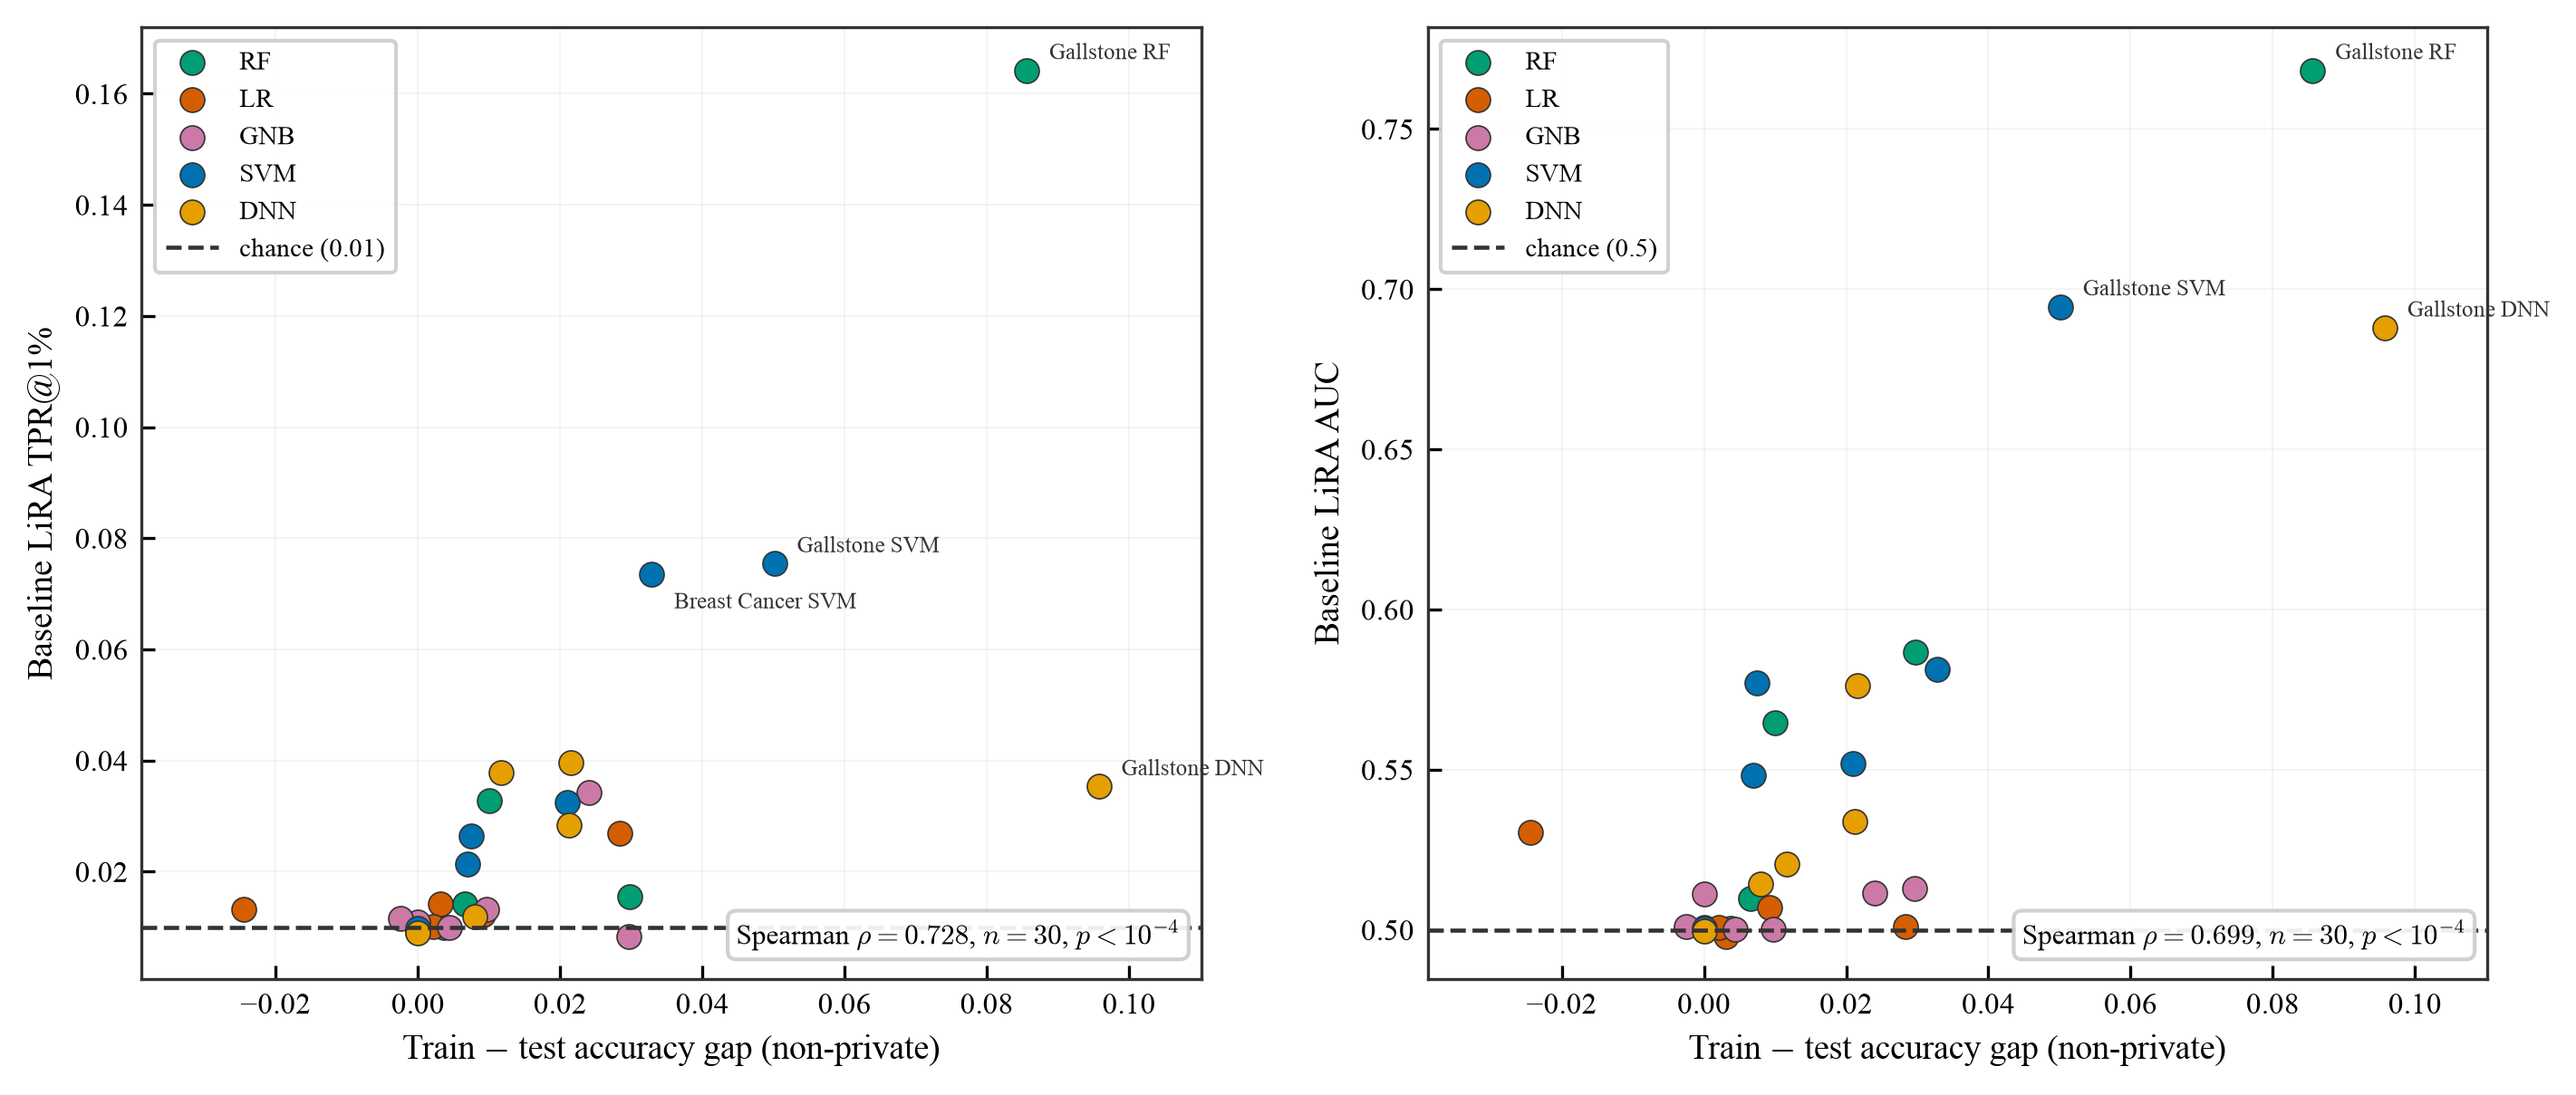

**The gap-based relationship beside the N-based one the paper currently tells. Gap: -5.5% under Lung Cancer removal; N: -14.2%.**

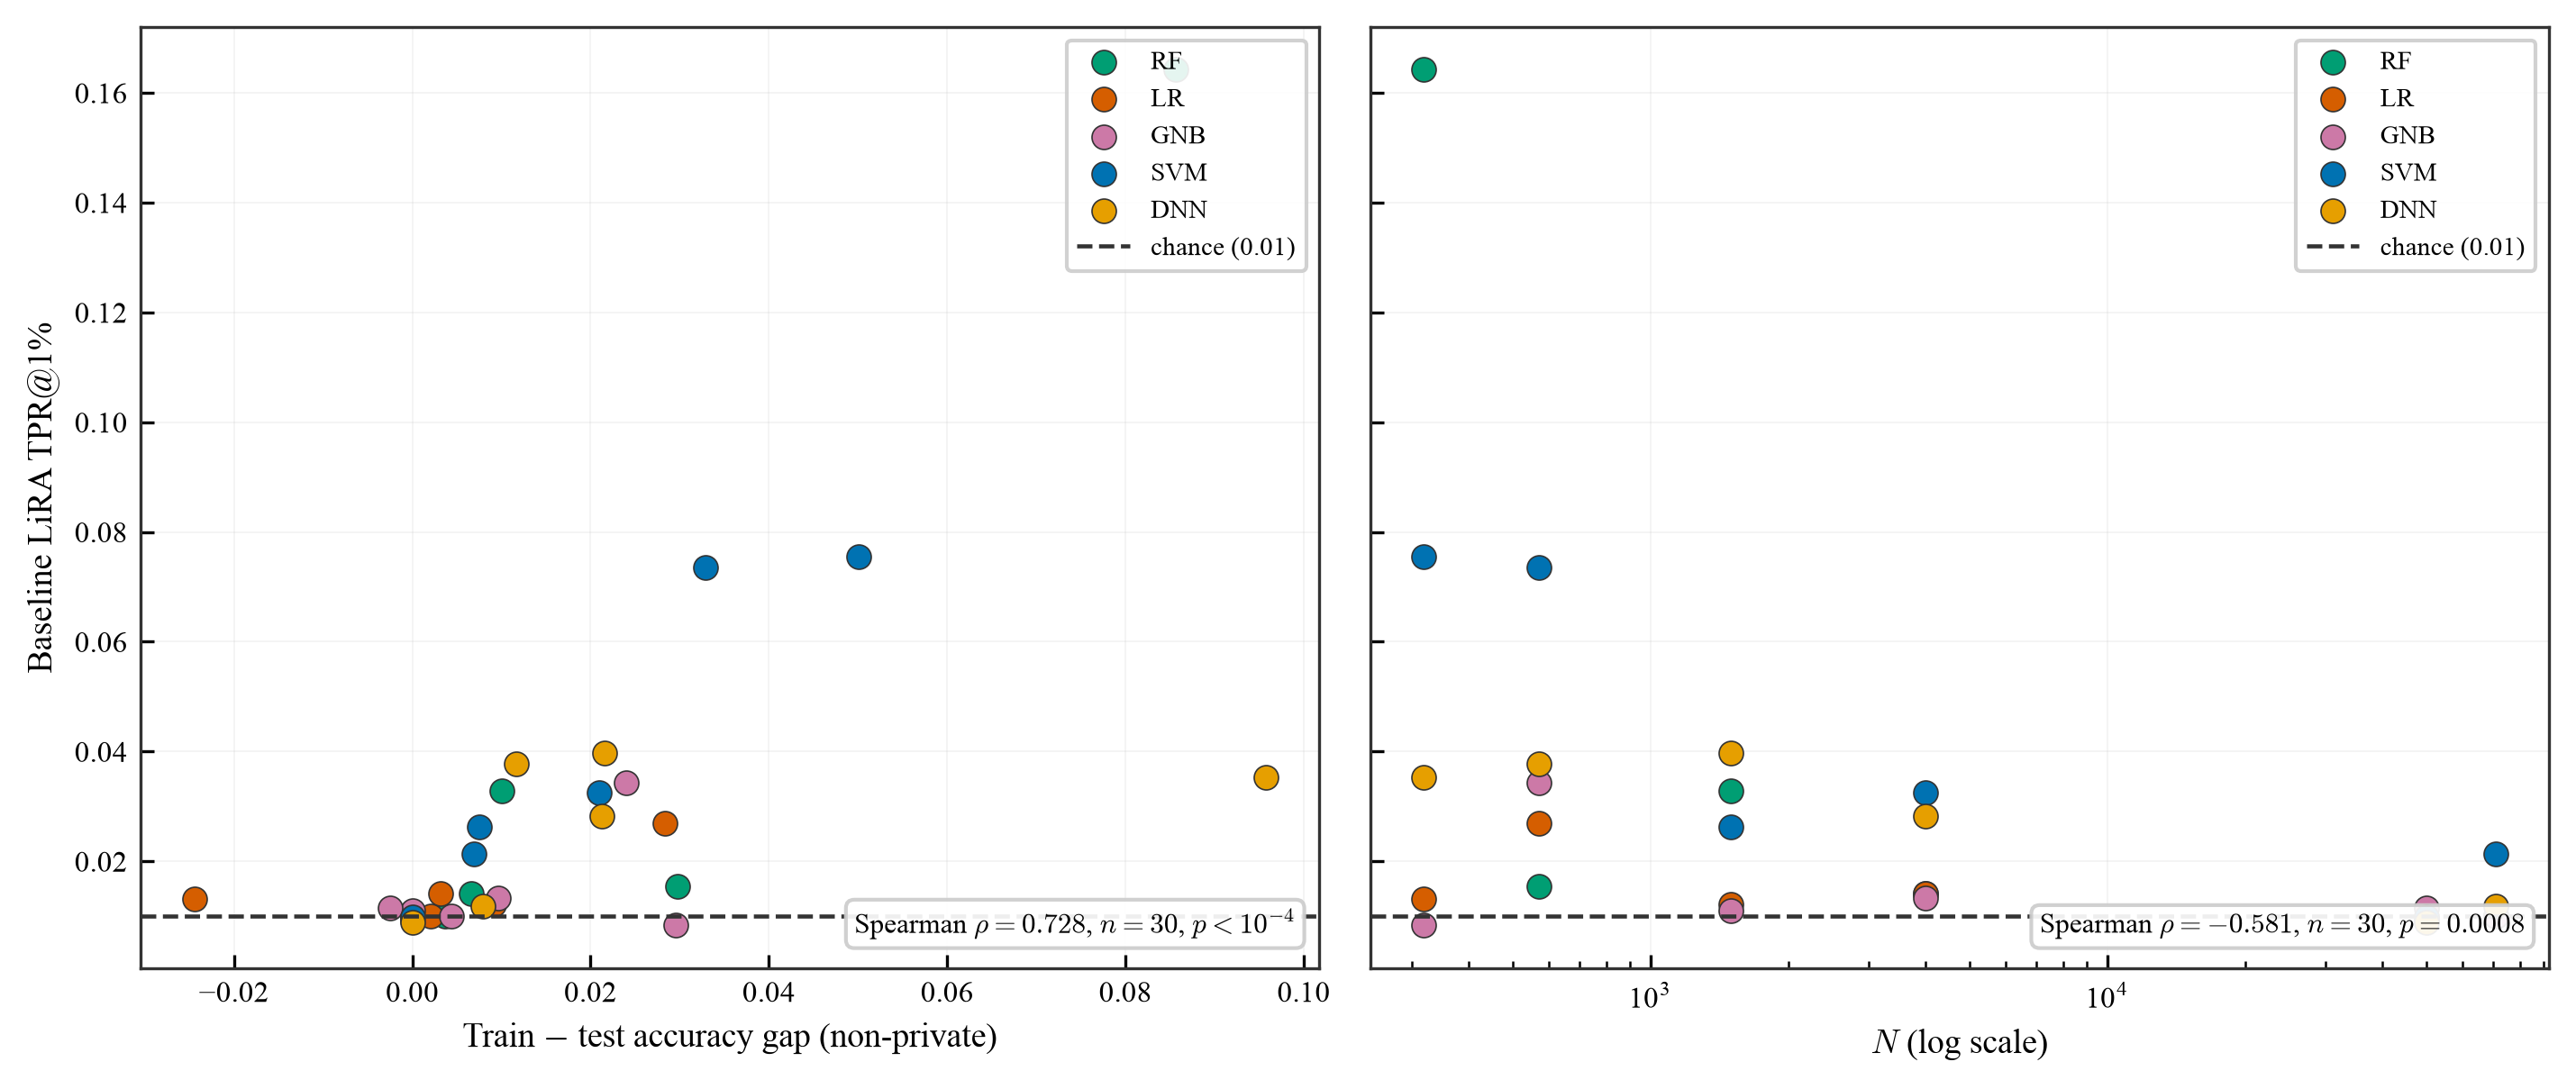

**Items [14][15] — residual floor with Clopper–Pearson intervals. Median 0.01206, IQR 0.00995–0.01456; 4 of 30 exclude chance.**

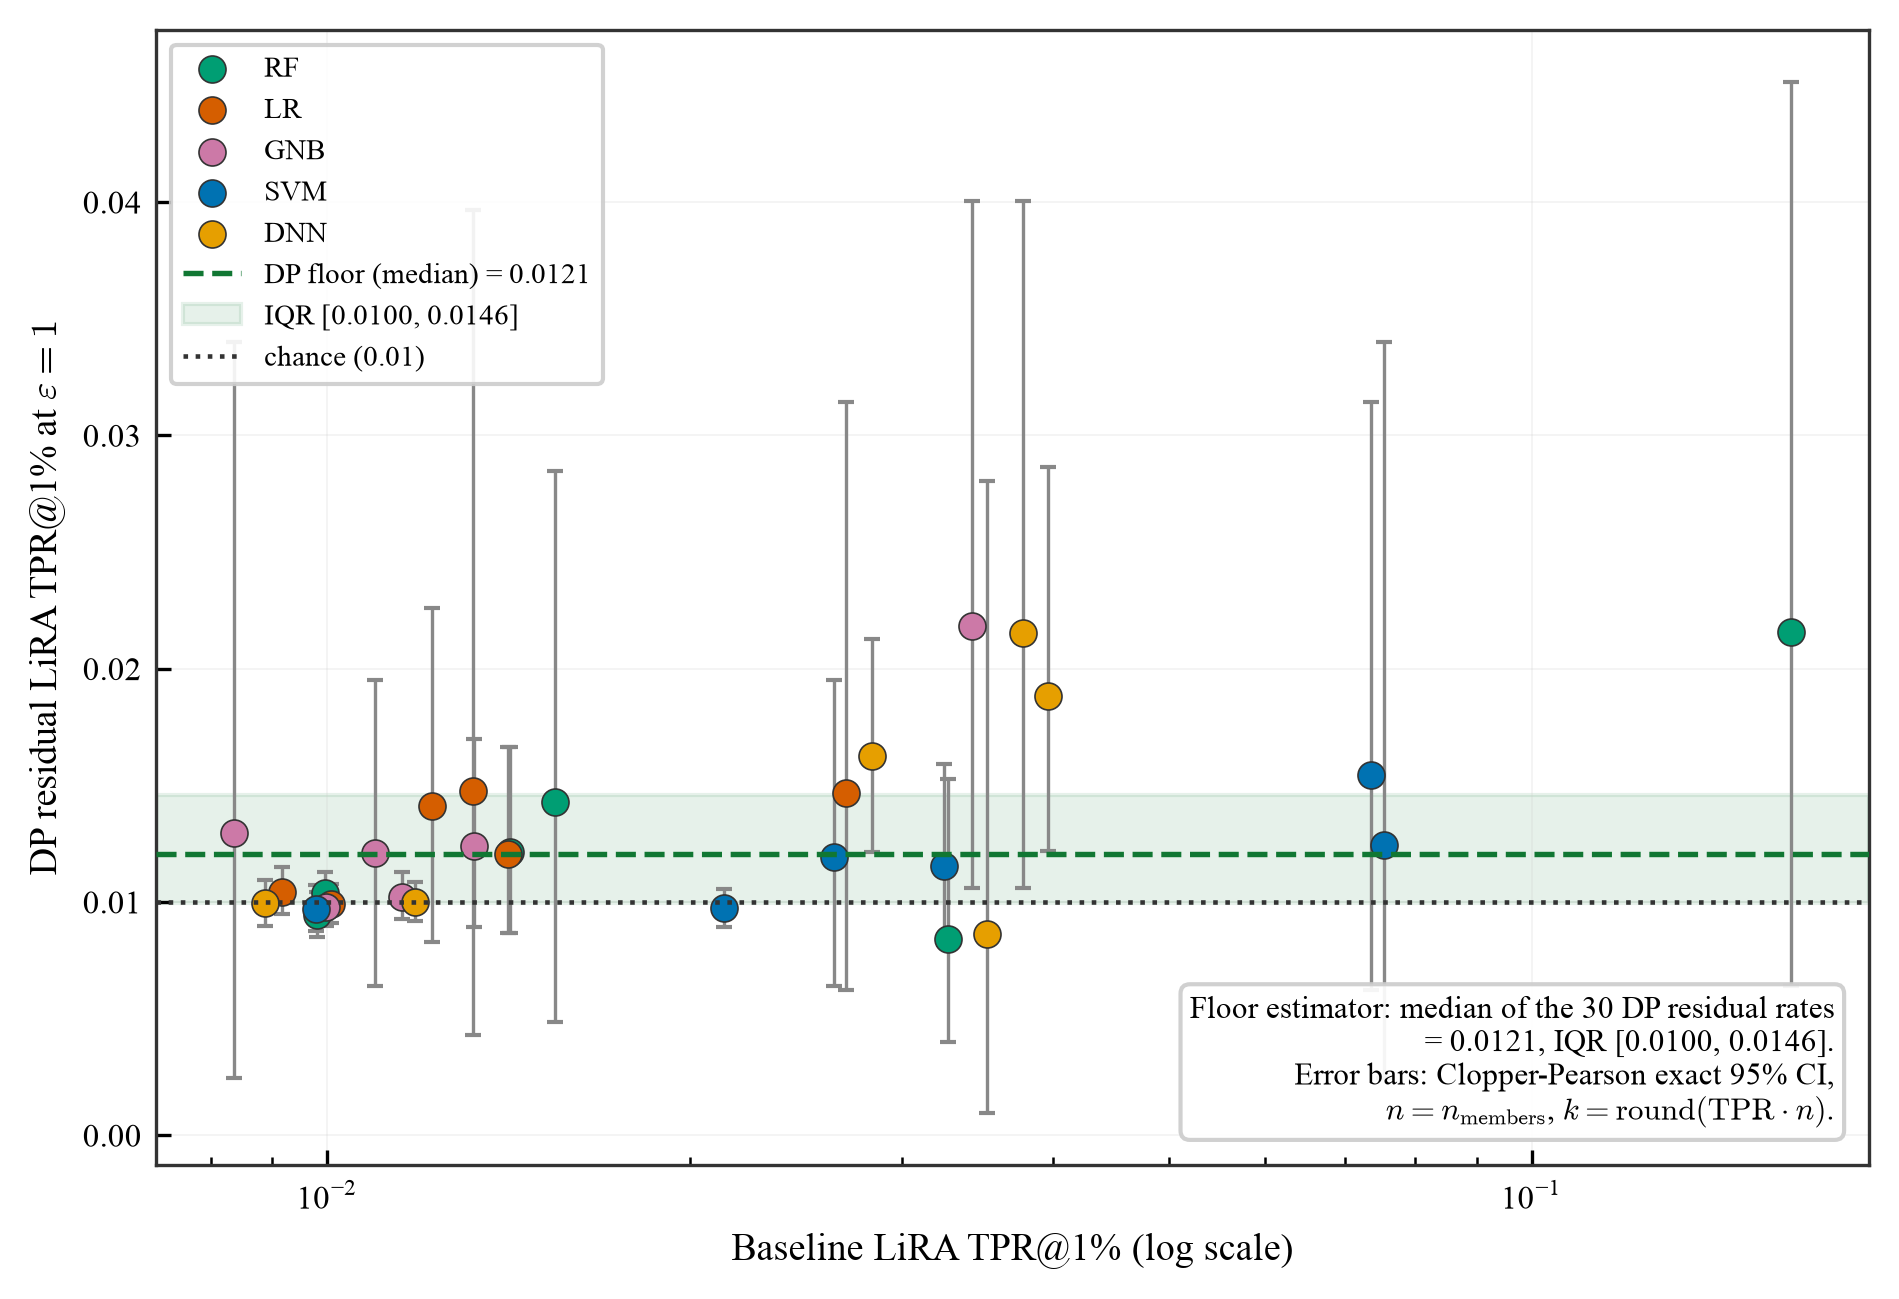

**Item [13] — reduction vs baseline. rho=0.9079, but reduction is defined as baseline minus residual, so this is largely arithmetic.**

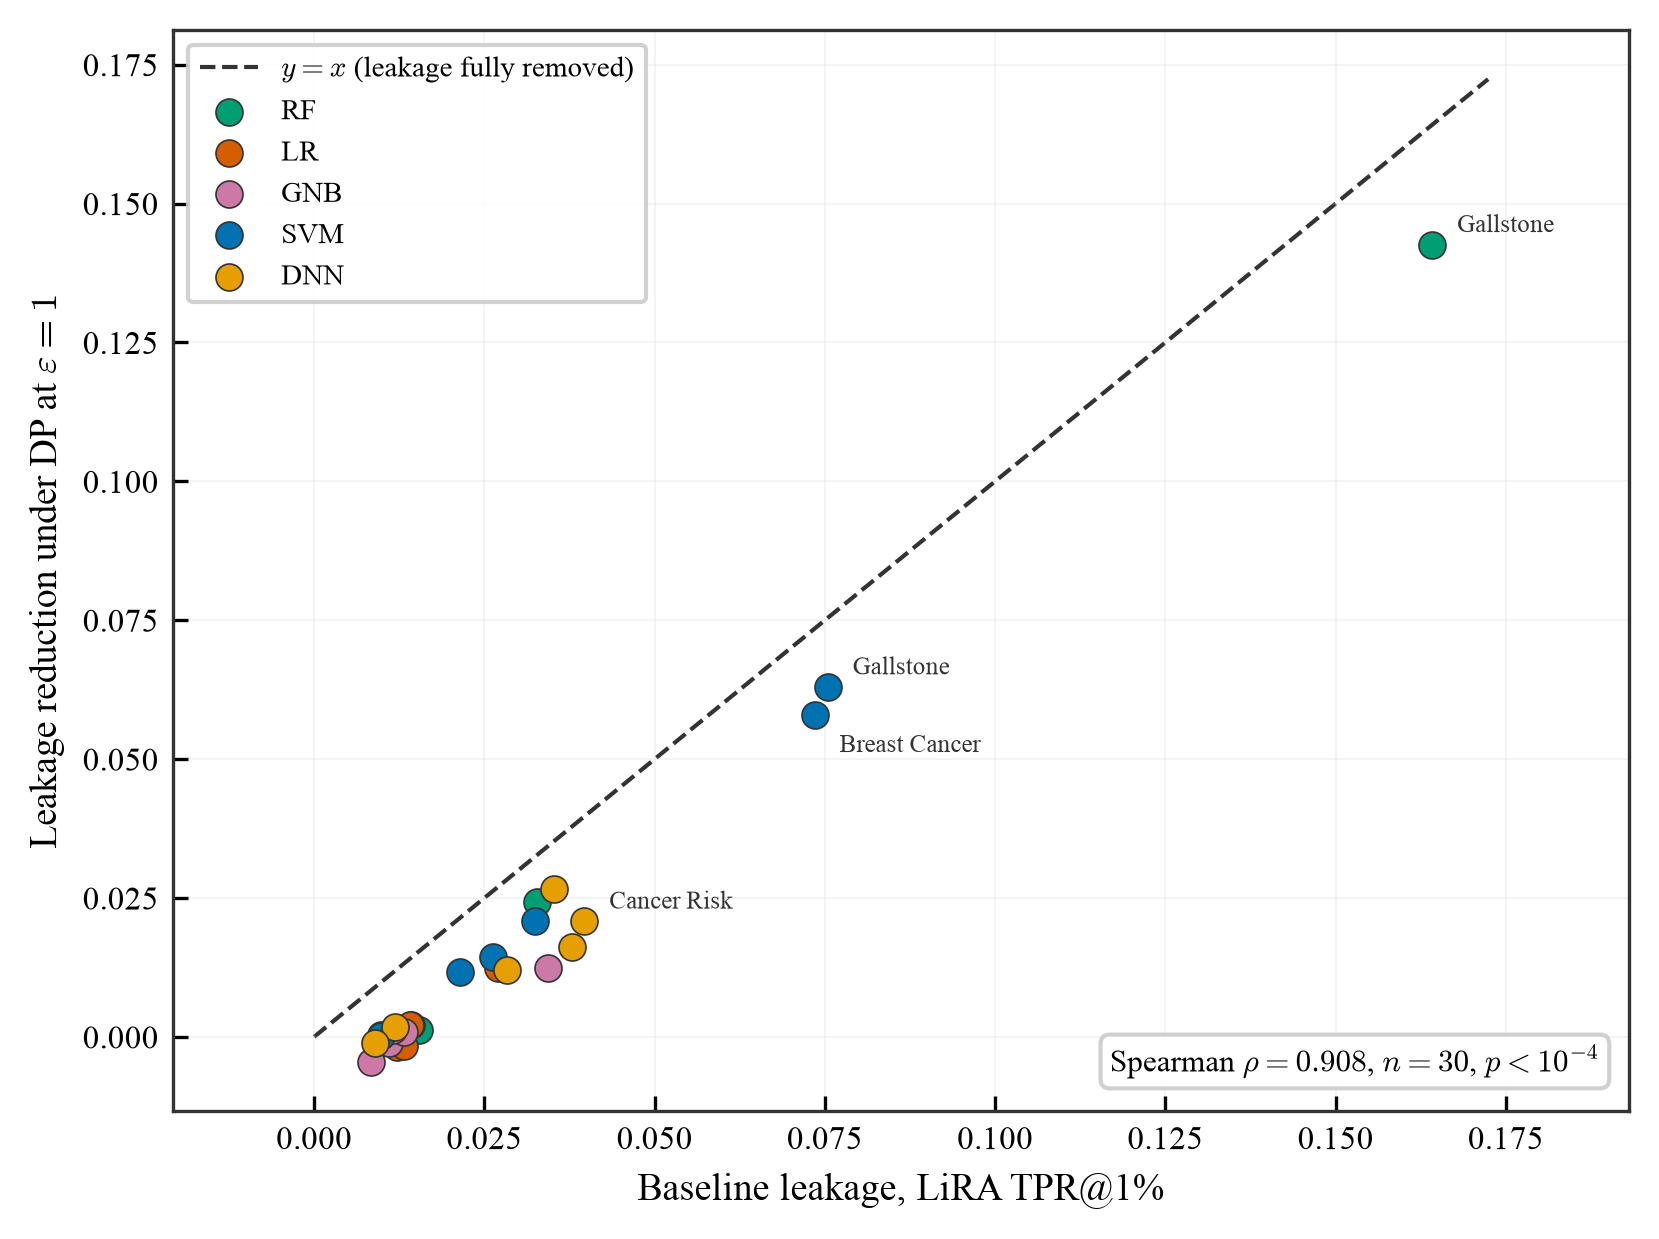

**ACL vs residual leakage at eps=1.0, all 30 pairs.**

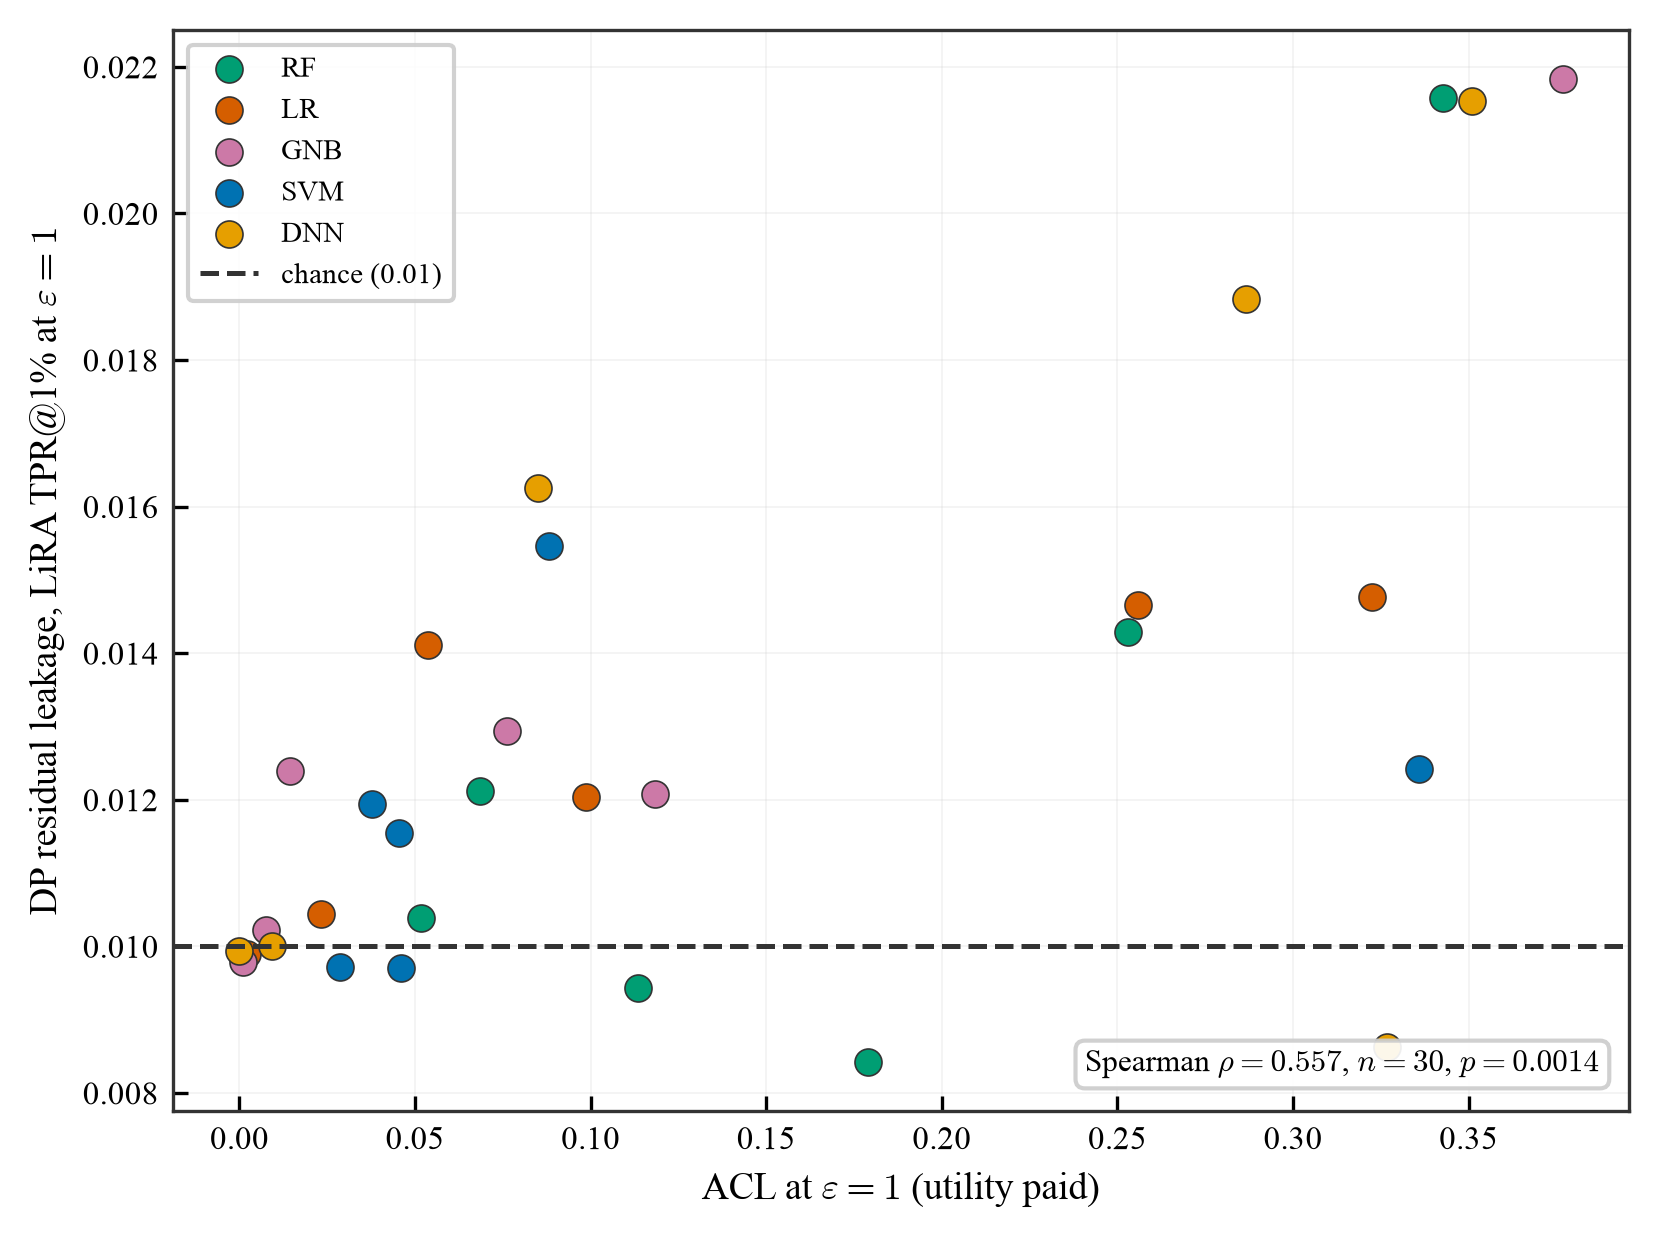

**Same on ACL_exported (26 of 30 — four DP-DNN rows lack exported accuracy). Different estimand, not a degraded copy.**

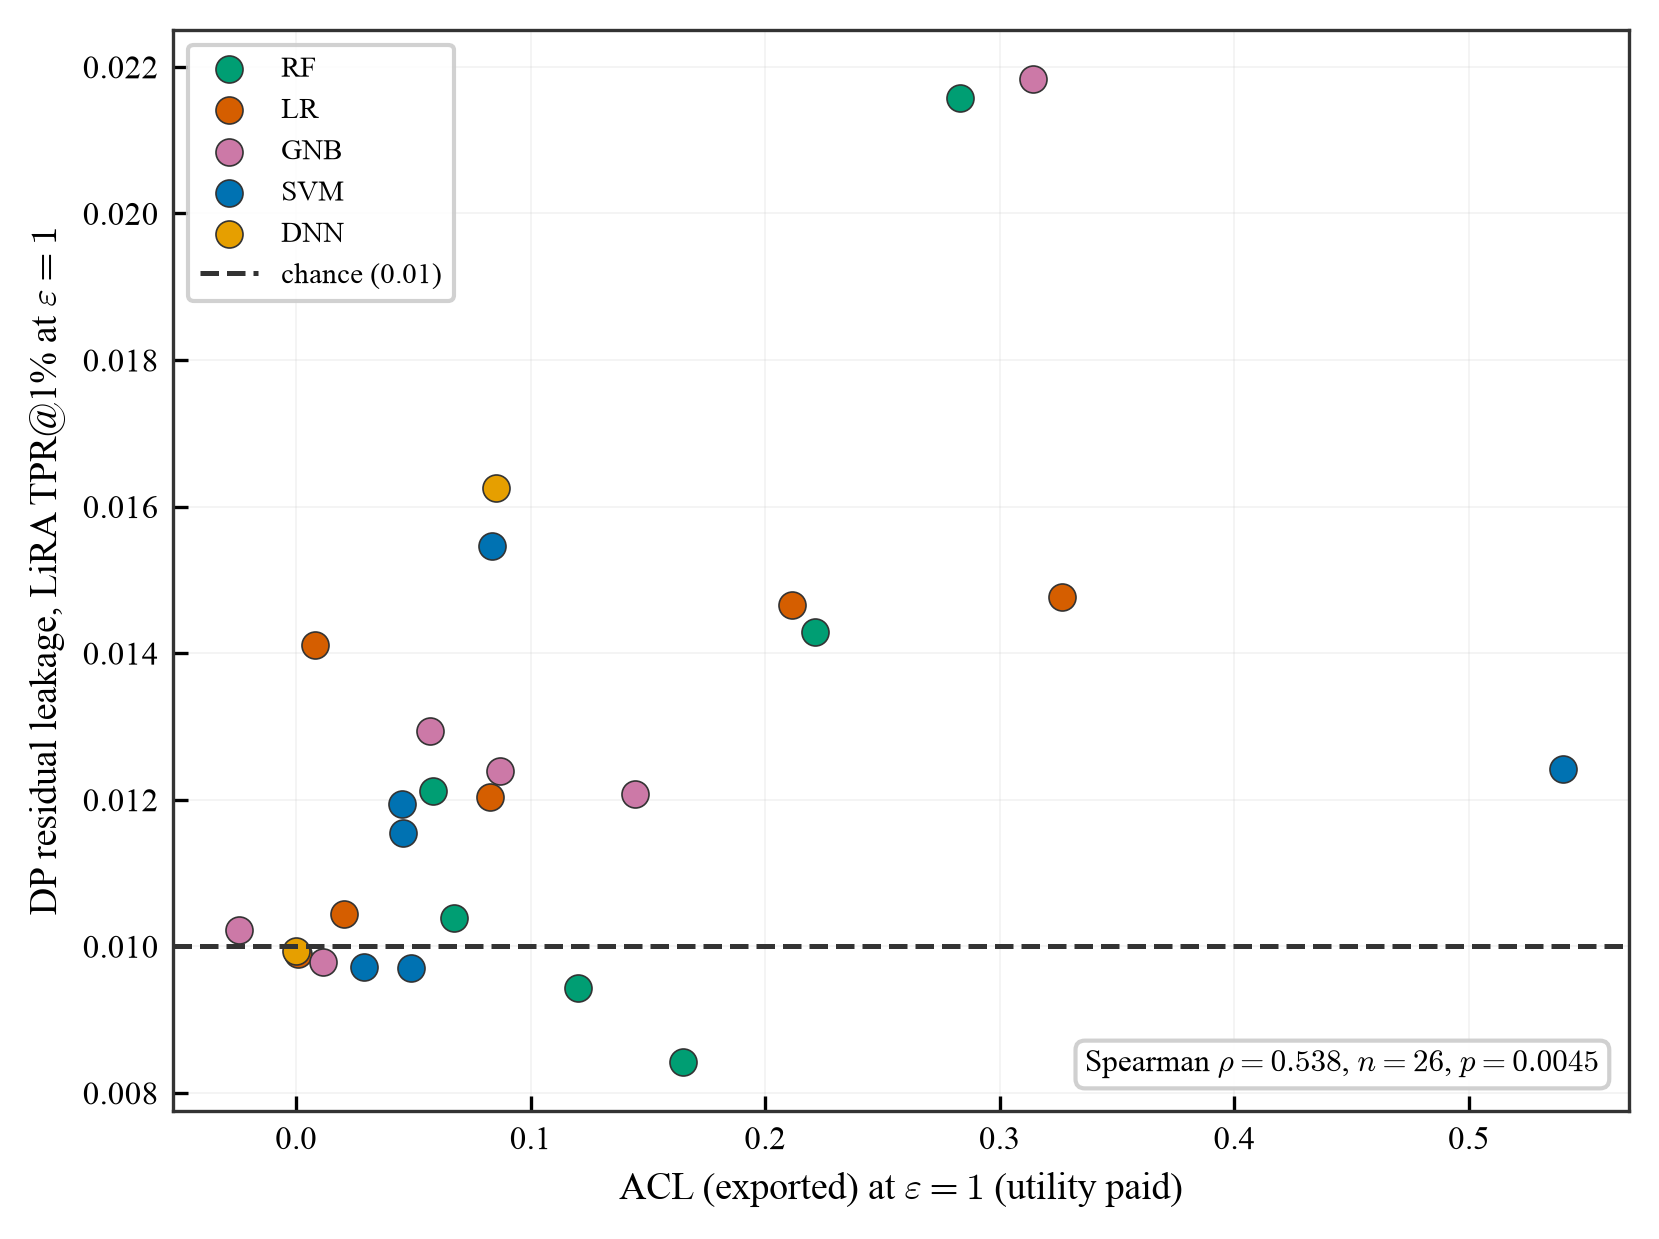

**Average-case vs worst-case agreement on non-private targets.**

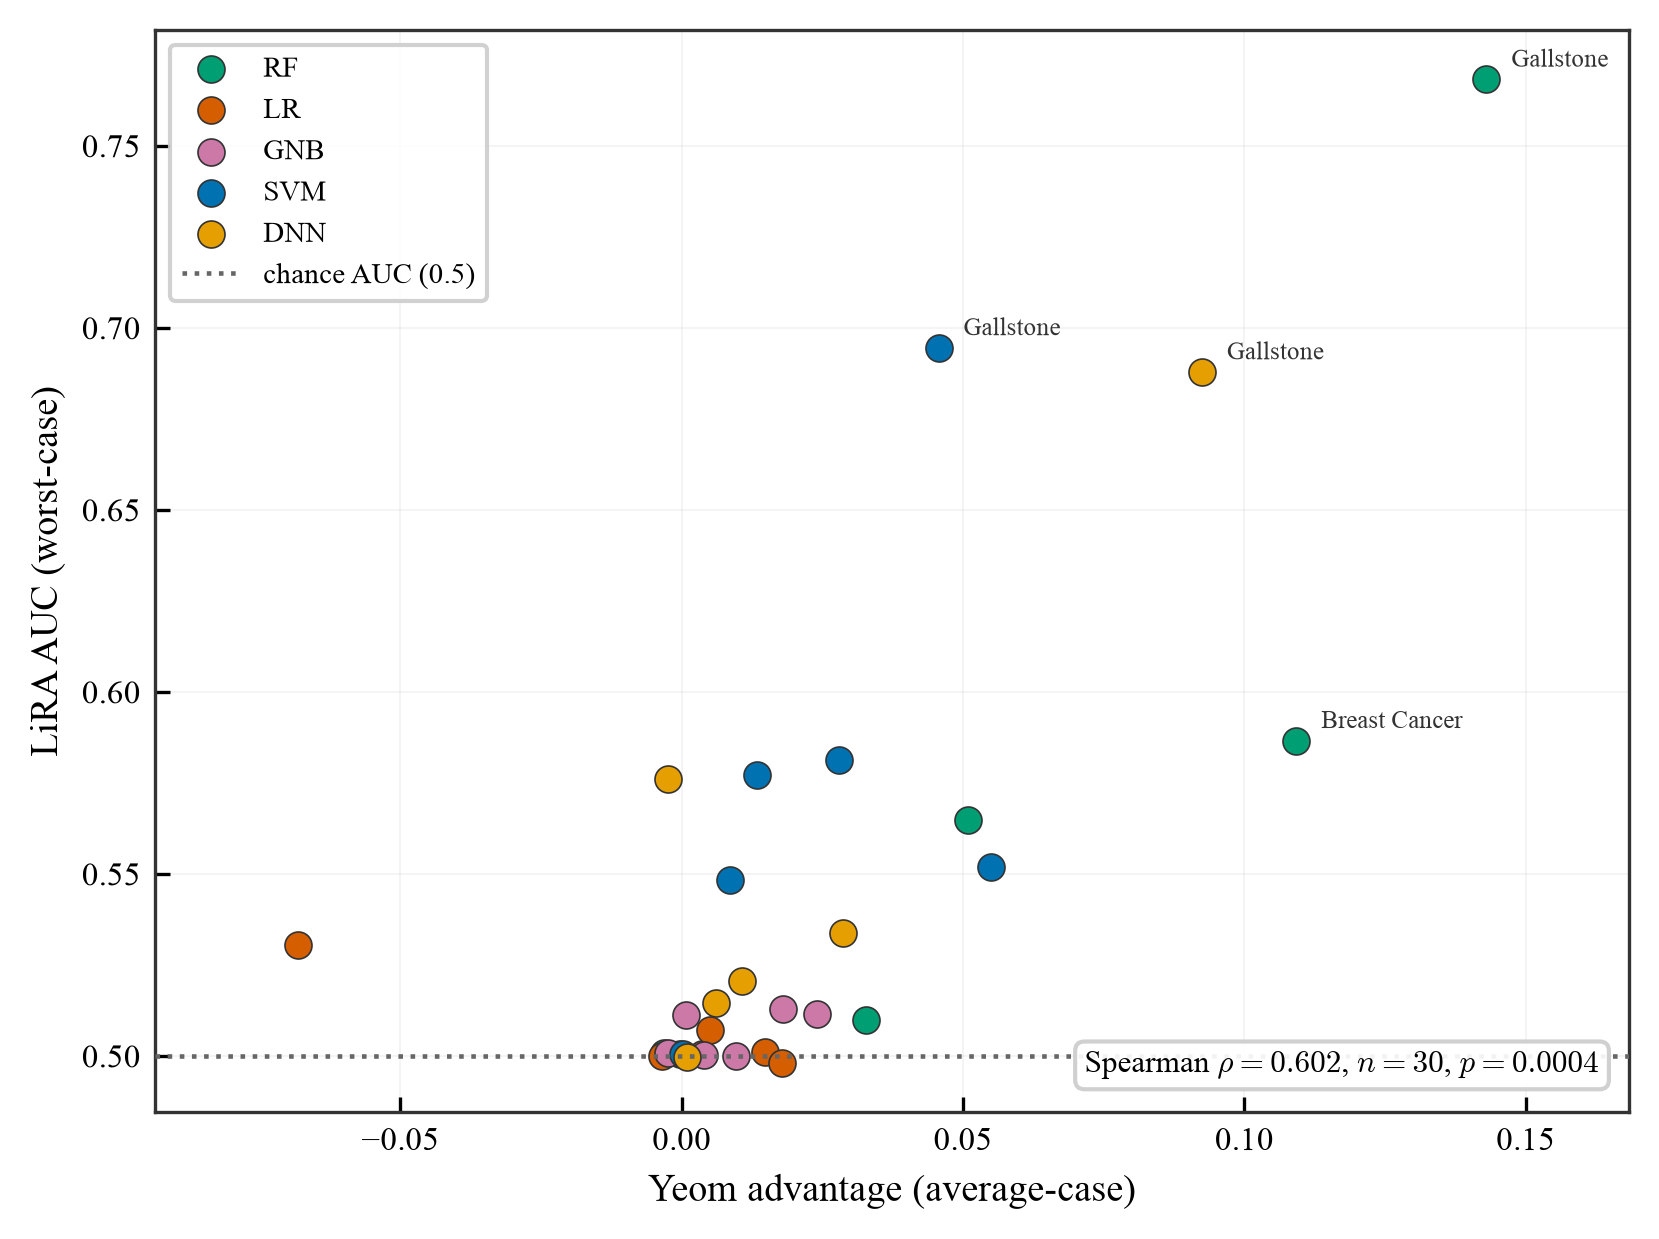

In [88]:
# ---- Figure pass 2: display, grouped by what each one argues ----------
def show(stem, caption):
    display(Markdown(f"**{caption}**"))
    display(Image(filename=str(FIGPNG / f"{stem}.png")))

show("gap_vs_leakage",
     "Items [51][65] — train–test gap vs baseline leakage. "
     "rho=+0.7284 (TPR@1%), +0.6990 (AUC), n=30.")
show("gap_vs_leakage_vs_N",
     "The gap-based relationship beside the N-based one the paper "
     "currently tells. Gap: -5.5% under Lung Cancer removal; N: -14.2%.")
show("residual_floor_ci",
     "Items [14][15] — residual floor with Clopper–Pearson intervals. "
     "Median 0.01206, IQR 0.00995–0.01456; 4 of 30 exclude chance.")
show("rq2a_benefit_vs_baseline",
     "Item [13] — reduction vs baseline. rho=0.9079, but reduction is "
     "defined as baseline minus residual, so this is largely arithmetic.")
show("rq1c_utility_vs_protection",
     "ACL vs residual leakage at eps=1.0, all 30 pairs.")
show("rq1c_utility_vs_protection_exported",
     "Same on ACL_exported (26 of 30 — four DP-DNN rows lack exported "
     "accuracy). Different estimand, not a degraded copy.")
show("l4_avg_vs_worst_case",
     "Average-case vs worst-case agreement on non-private targets.")

**Item [62] — log-log ROC, non-private targets only.** These were produced by the original LiRA run and copied unchanged: the ROC arrays are stripped before the CSV write, so DP curves cannot be regenerated without re-running the attack. The two-line in-image title remains — the crop was attempted, inspected, and abandoned because the lower title line shares pixel rows with the top y-tick label.

*GALLSTONE*

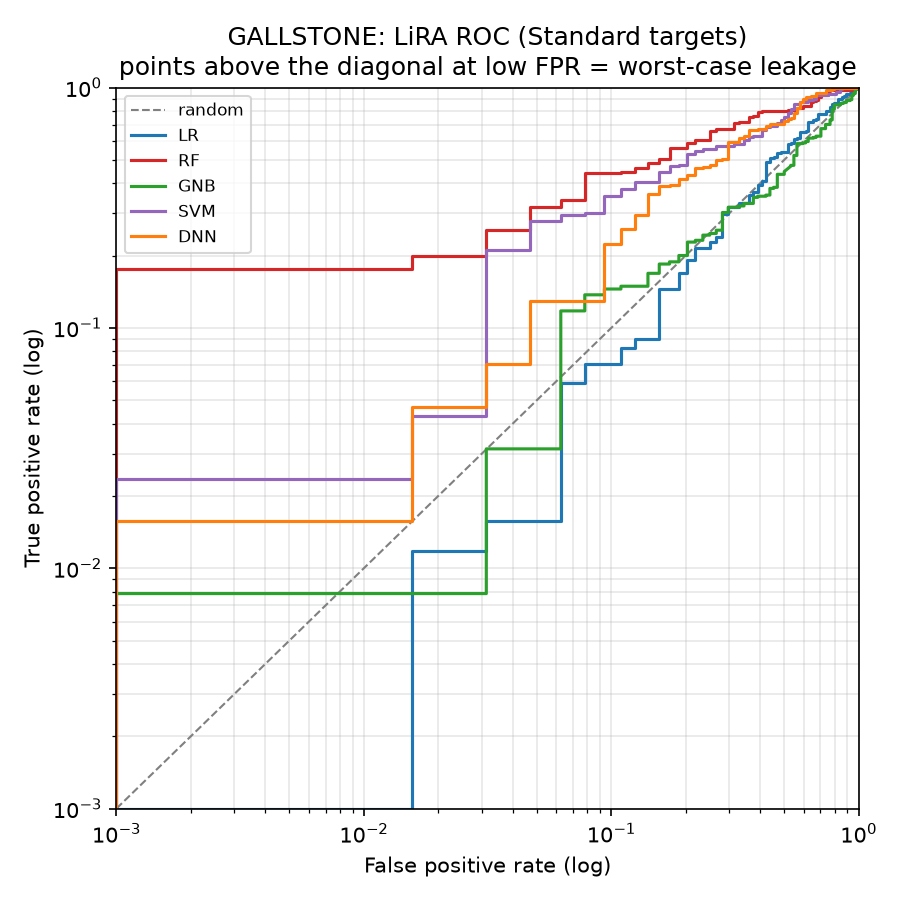

*BCP*

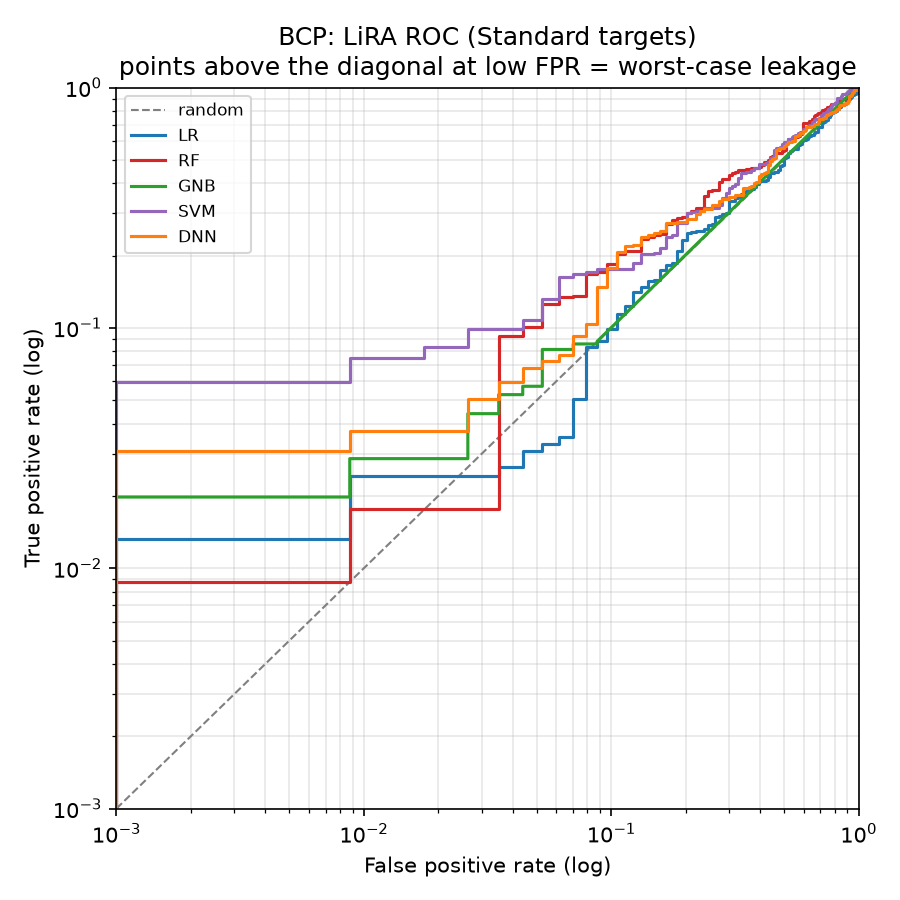

*CANCER_RISK*

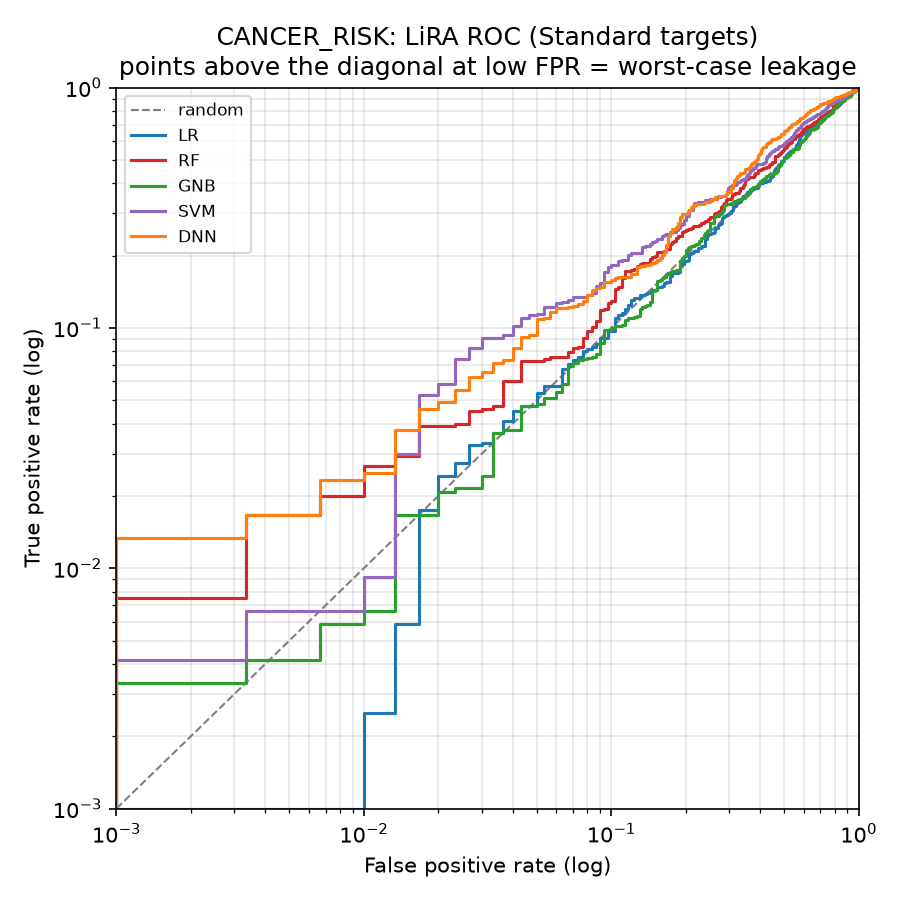

*KIDNEY_STONE*

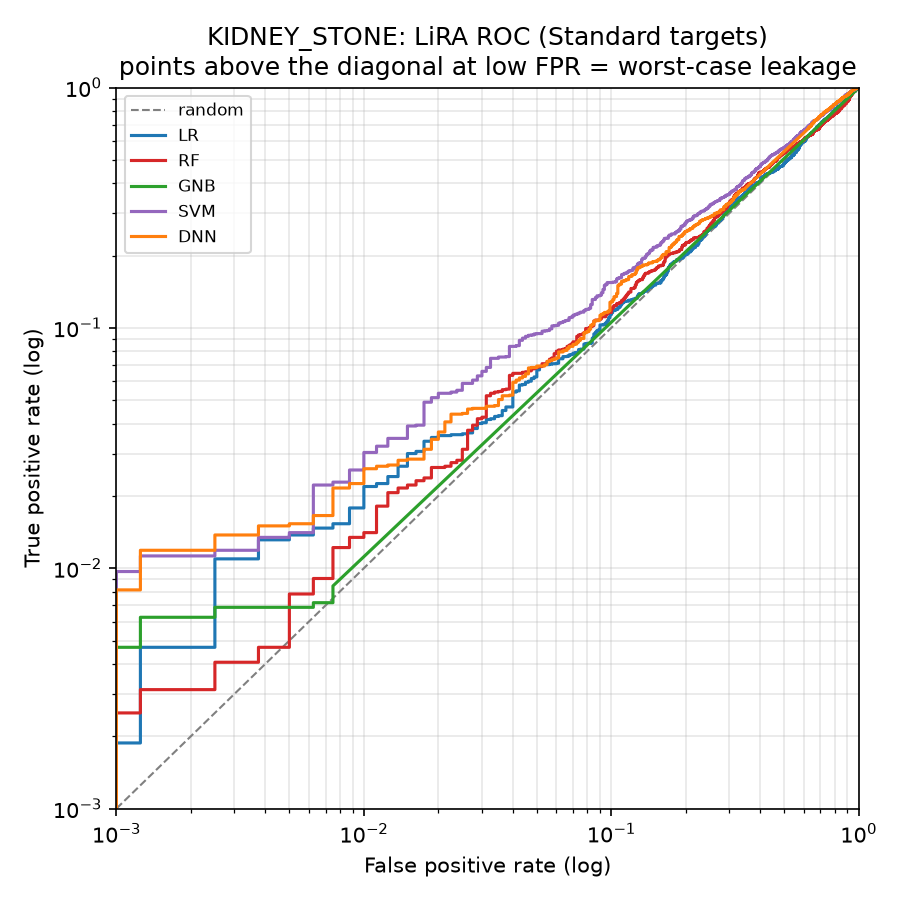

*LUNG_CANCER*

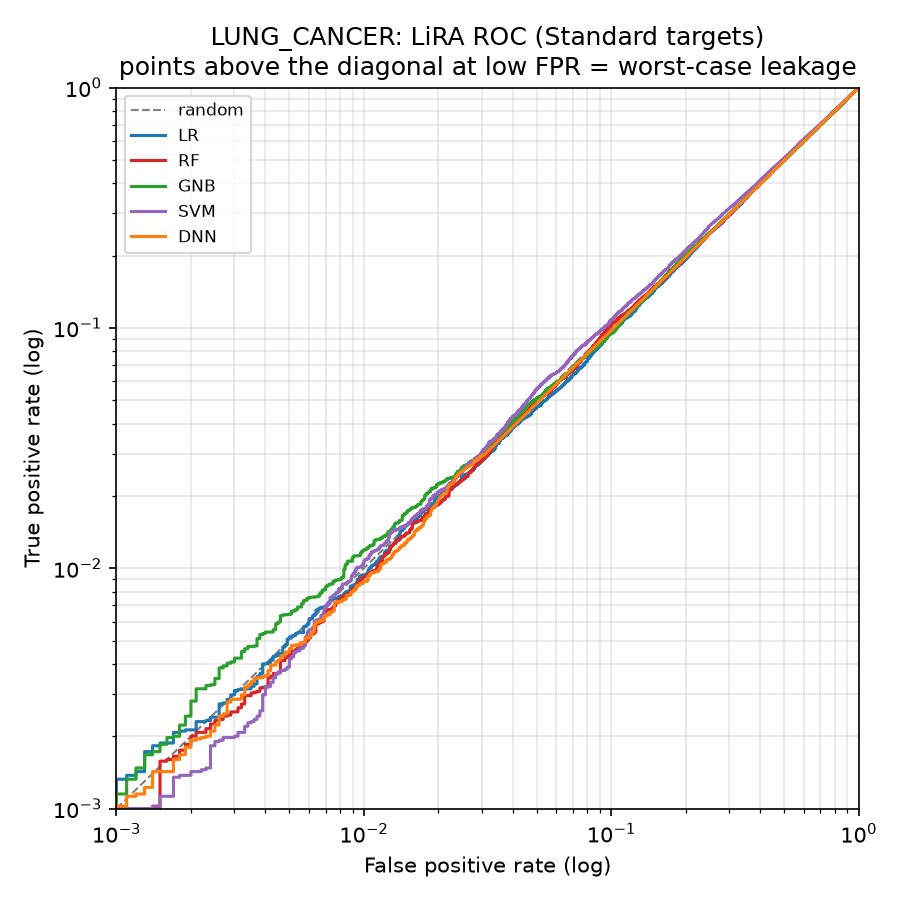

*DIABETES*

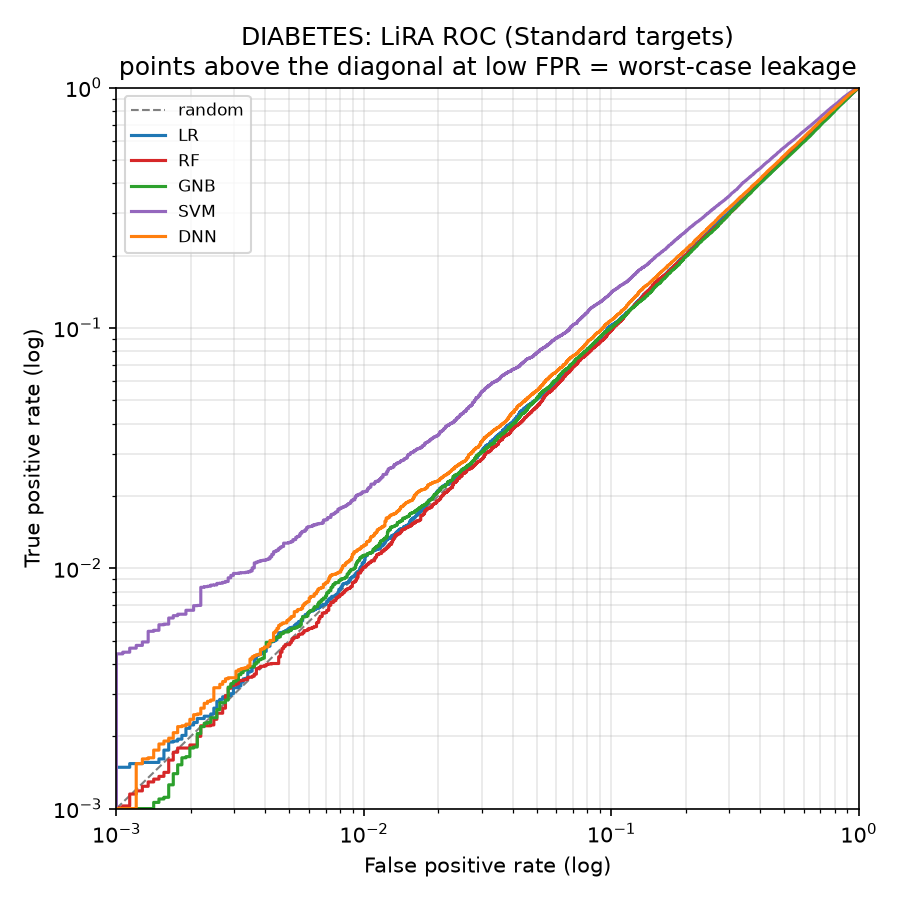

In [89]:
# ---- Figure pass 3: the six relocated ROC curves ----------------------
display(Markdown(
    "**Item [62] — log-log ROC, non-private targets only.** These were "
    "produced by the original LiRA run and copied unchanged: the ROC arrays "
    "are stripped before the CSV write, so DP curves cannot be regenerated "
    "without re-running the attack. The two-line in-image title remains — "
    "the crop was attempted, inspected, and abandoned because the lower "
    "title line shares pixel rows with the top y-tick label."
))
for ds in ["GALLSTONE", "BCP", "CANCER_RISK", "KIDNEY_STONE",
           "LUNG_CANCER", "DIABETES"]:
    display(Markdown(f"*{ds}*"))
    display(Image(filename=str(FIGPNG / f"loglog_roc_{ds}.png")))

In [90]:
# ---- Figure pass 4: what the set does NOT cover -----------------------
display(Markdown("**Outstanding figure-related referee items**"))
for item, what, status in [
    (62, "log-log ROC for DP variants", "NOT COVERED — needs re-run"),
    (72, "in-image titles on the six ROC files", "PARTIAL — crop unsafe"),
    (74, "Figure 5 unreadable at print size", "not in this package"),
    (76, "Figure 14 log axis, zero handling", "check l6 / residual_floor"),
    (77, "Shokri AUC below 0.5 discussed", "unassigned — Tier 2b: 8/30 baselines"),
    (78, "merge Figures 1–2, use space for ROC", "manuscript-side decision"),
]:
    print(f"  [{item:>2}] {what:<42} {status}")

print(f"\nVector coverage: {len(pdf)} of {len(png)} figures have a PDF twin.")
print("The six ROC PNGs are raster-only; MDPI prefers vector.")

**Outstanding figure-related referee items**

  [62] log-log ROC for DP variants                NOT COVERED — needs re-run
  [72] in-image titles on the six ROC files       PARTIAL — crop unsafe
  [74] Figure 5 unreadable at print size          not in this package
  [76] Figure 14 log axis, zero handling          check l6 / residual_floor
  [77] Shokri AUC below 0.5 discussed             unassigned — Tier 2b: 8/30 baselines
  [78] merge Figures 1–2, use space for ROC       manuscript-side decision

Vector coverage: 8 of 14 figures have a PDF twin.
The six ROC PNGs are raster-only; MDPI prefers vector.
